<a href="https://colab.research.google.com/github/icosrle31/Test_ENNOH/blob/main/Electricity_cases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Electricty Netowork Optimisation

In [ ]:
! pip install pypsa highspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.3/347.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.7 MB/s eta 0:00:00


## Import data

In [ ]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/PyPSA/Zonal_model/data/")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json

file_path = PROJECT_DIR + 'input_data.json'

try:
    with open(file_path, 'r') as f:
        loaded_data = json.load(f)
    print(f"Successfully loaded data from {file_path}:")
    # print(json.dumps(loaded_data, indent=2)) # Uncomment to see full content
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please ensure it exists and your Google Drive is mounted correctly.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {file_path}. The file might be corrupted or not a valid JSON.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Mounted at /content/drive
Successfully loaded data from /content/drive/MyDrive/Colab_Notebooks/PyPSA/Zonal_model/data/input_data.json:


In [ ]:
optimization_inputs = loaded_data.get('optimization_inputs')
elec_generators = loaded_data.get('elec_generators')

In [ ]:
input_profiles_path = PROJECT_DIR + 'input_profiles.csv'

try:
    input_profiles = pd.read_csv(input_profiles_path, index_col=0, parse_dates=True)

    print("Head of input_profiles with datetime index (first 4 rows):")
    print(input_profiles.head(4))
except FileNotFoundError:
    print(f"Error: The file {input_profiles_path} was not found. Please ensure it exists.")
except Exception as e:
    print(f"An error occurred while loading input_profiles: {e}")

Head of input_profiles with datetime index (first 4 rows):
                     df_solar   df_wind  combined_p_max_pu  combined_p_min_pu  \
2040-01-01 00:00:00       0.0  0.016622           0.633086           0.016657   
2040-01-01 01:00:00       0.0  0.013083           0.633086           0.016657   
2040-01-01 02:00:00       0.0  0.018244           0.633086           0.016657   
2040-01-01 03:00:00       0.0  0.024824           0.633086           0.016657   

                     combined_p_inflow_pu  elec_profile_2040_scaled  
2040-01-01 00:00:00               0.35237               1362.114747  
2040-01-01 01:00:00               0.35237               1290.694858  
2040-01-01 02:00:00               0.35237               1297.022225  
2040-01-01 03:00:00               0.35237               1320.336482  


## Electricity Networks

In [ ]:
# Slicing inputs for June only
period_snapshots = input_profiles.loc['2040-09-10':'2040-09-17'].index

In [ ]:
marginal_cost = {
    "solar": 1.5,
    "import": 85.0,
    "coal": 63.0,
    "nuclear": 12.0
}

storage_parameters = {
    "capacity": 3000,
    "power": 1000,
    "charging_efficiency": 0.95,
    "discharging_efficiency": 0.95
}

### Case 1 - Import and Solar Interaction (Baseline)

This foundational case models a simple electricity system relying on two primary sources: intermittent solar energy and dispatchable imports. It serves as a baseline to understand basic merit-order dispatch.

*   **Generation Mix**: Consists of Solar (very low marginal cost, variable) and Imports (high marginal cost, flexible).
*   **Dispatch Strategy**: The system strictly follows the merit order, prioritizing 'must-take' Solar whenever available. Imports are used to fill 100% of the remaining demand gap.
*   **Price Dynamics**: Because solar capacity is insufficient to meet demand on its own during this period, the expensive Import generator remains the marginal unit, resulting in a constant, high electricity price (85.0 EUR/MWh).

In [ ]:
# INITIALIZE ELECTRICTY NETWORK ---
n_c1 = pypsa.Network()

# define snapshots
n_c1.set_snapshots(period_snapshots)

# define carrier
n_c1.add("Carrier", "AC")

# define bus
n_c1.add("Bus", "Elec", carrier="AC")

In [ ]:
# define load
n_c1.add("Load", "Load_elec", bus="Elec", p_set=input_profiles.loc[n_c1.snapshots, 'elec_profile_2040_scaled'], overwrite=True)

# define import as simple generator
n_c1.add("Generator", "Import_elec",
    bus="Elec",
    p_nom=5000.0,
    marginal_cost=marginal_cost['import'],
    carrier="AC",
    overwrite=True)

# define solar
n_c1.add("Generator", "Solar",
    bus="Elec",
    p_nom=elec_generators['Solar']['p_nom'],
    marginal_cost=marginal_cost['solar'],
    carrier="AC",
    p_max_pu=input_profiles.loc[n_c1.snapshots, 'df_solar'].values,
    overwrite=True)

# Optimization - Case 1
result_c1 = n_c1.optimize(solver_name='highs', include_objective_constant=False)

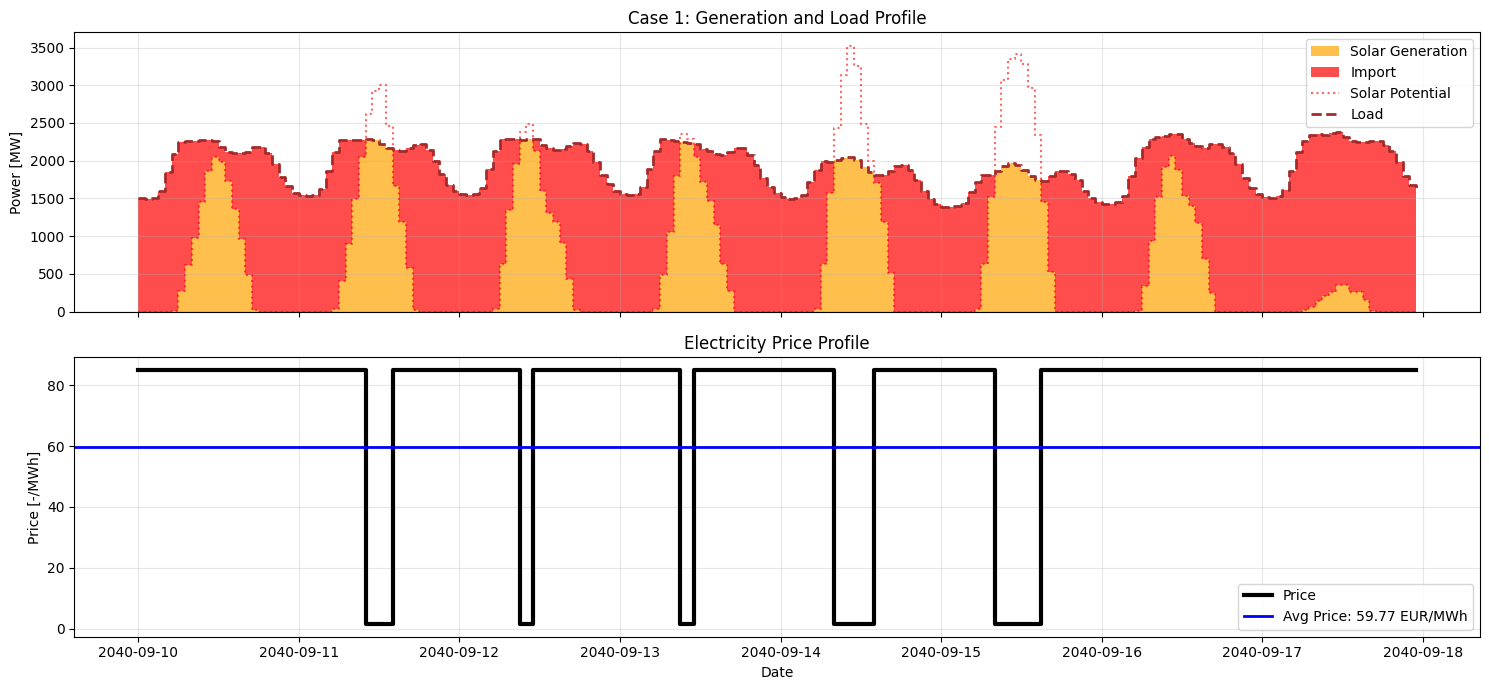

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract required generation data from the network ---
import_prof = n_c1.generators_t.p['Import_elec']
solar_prof = n_c1.generators_t.p['Solar']
load_prof = n_c1.loads_t.p['Load_elec']

# Extract solar potential (p_max_pu * p_nom)
solar_p_nom = n_c1.generators.at['Solar', 'p_nom']
solar_potential = n_c1.generators_t.p_max_pu['Solar'] * solar_p_nom

# Extract marginal price (electricity price) at the bus
elec_price = n_c1.buses_t.marginal_price['Elec']

# Calculate average marginal price for Case 1
total_cost_c1 = n_c1.objective
total_load_energy_c1 = n_c1.loads_t.p['Load_elec'].sum()
avg_marginal_price_c1 = total_cost_c1 / total_load_energy_c1

# Create a figure with 2 subplots (2 rows, 1 column), sharing the x-axis
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# 1. Generation and Load Profile
y_stack_gen = [solar_prof.values, import_prof.values]
labels_gen = ['Solar Generation', 'Import']
colors_gen = ['orange', 'red']

axes[0].stackplot(solar_prof.index, y_stack_gen, labels=labels_gen, colors=colors_gen, step='post', alpha=0.7)

# Plot Solar Potential
axes[0].step(solar_potential.index, solar_potential.values, where='post', color='red', linestyle='dotted', alpha=0.60, label='Solar Potential')

# Plot Load
axes[0].step(load_prof.index, load_prof.values, where='post', color='brown', linestyle='--', linewidth=2, label='Load')

# Generation and Load Profile
axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_title('Case 1: Generation and Load Profile', fontsize=12)
axes[0].set_ylabel('Power [MW]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Electricity Price
axes[1].step(elec_price.index, elec_price.values, where='post', color='black', linewidth=3, label='Price')
axes[1].axhline(avg_marginal_price_c1, color='blue', linestyle='-', linewidth=2, label=f'Avg Price: {avg_marginal_price_c1:,.2f} EUR/MWh')
axes[1].set_title('Electricity Price Profile', fontsize=12)
axes[1].set_ylabel('Price [-/MWh]')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate results for Case 1
import_cost_c1 = (n_c1.generators_t.p['Import_elec'] * n_c1.generators.at['Import_elec', 'marginal_cost']).sum()
solar_cost_c1 = (n_c1.generators_t.p['Solar'] * n_c1.generators.at['Solar', 'marginal_cost']).sum()

# Calculate total demand for the period
total_demand_c1 = input_profiles.loc[period_snapshots, 'elec_profile_2040_scaled'].sum()

**Summary: Import and Solar Interaction**

This case establishes a foundational understanding of electricity dispatch based on a simple merit-order system with limited generation options.

*1. System Objective:*
*   The primary objective is to minimize the total system cost to meet the electricity demand over the period.

*2. Demand Coverage and Dispatch Strategy:*
*   **Solar Generation (Low Marginal Cost: 1.5 EUR/MWh)**: Solar is prioritized and dispatched first whenever available due to its very low marginal cost. If solar production exceeds the load, the excess energy is curtailed, as there's no storage or alternative use in this scenario.
*   **Imports (High Marginal Cost: 85.0 EUR/MWh)**: Imports act as the primary dispatchable resource, filling any remaining demand not met by solar. Since solar alone is insufficient to meet demand for most of the simulated period, imports are consistently utilized to balance the system.

*3. Price Determination:*
*   The electricity price (marginal price) is set by the most expensive generator required to meet the last unit of demand. In this case, because imports are almost always needed to cover the load, they set the system price consistently at import price. If solar generation were ever abundant enough to meet demand entirely, the price would drop to solar's marginal cost.

*4. Quantitative Results (for `period_snapshots`):*
*   **Total System Cost**: `22,327,558.78` EUR
*   **Cost from Imports**: `22,158,230.13` EUR (approx. 99.2% of total cost)
*   **Cost from Solar**: `169,328.65` EUR (approx. 0.8% of total cost)
*   **Total Electricity Demand**: `373,570.83` MWh

*Overall Takeaway:*

Case 1 highlights the significant cost implications and flat price profile when relying heavily on an expensive, dispatchable source (imports) to balance a system with limited low-cost, flexible generation and no energy storage capabilities.

### Case 2 - National Mix Supported by Imports

This case introduces a more diverse generation mix compared to Case 1, including baseload nuclear, dispatchable coal with ramping capabilities, solar, and imports. The objective remains to minimize system costs while meeting demand.

*   **Generation Mix**: Includes Nuclear (baseload, low marginal cost), Solar (intermittent, very low marginal cost), Coal (dispatchable, moderate marginal cost with ramp limits), and Imports (expensive, flexible).
*   **Dispatch Strategy**: Nuclear and Solar are prioritized due to their low costs. Coal provides flexibility and follows the remaining load, while imports serve as a last resort to cover peak demand or when other generators are constrained.
*   **Price Dynamics**: Prices become more dynamic, influenced by the marginal costs of Coal and Imports, and occasionally Solar or Nuclear if they become marginal. The overall system cost is significantly reduced compared to Case 1 due to less reliance on expensive imports.

In [ ]:
# CASE 2 - Step 1: Initialize Network
n_c2 = pypsa.Network()
n_c2.set_snapshots(period_snapshots)
n_c2.add("Carrier", "AC")
n_c2.add("Bus", "Elec", carrier="AC")

In [ ]:
# define load
n_c2.add("Load", "Load_elec", bus="Elec", p_set=input_profiles.loc[n_c2.snapshots, 'elec_profile_2040_scaled'])

# Nuclear (Baseload)
n_c2.add("Generator", "Nuclear",
    bus="Elec", carrier="AC",
    p_nom=elec_generators['Nuclear']['p_nom'],
    marginal_cost=marginal_cost['nuclear'],
    p_min_pu=1.0,
    overwrite=True)

# Coal (Dispatchable with Ramping)
n_c2.add("Generator", "Coal",
    bus="Elec", carrier="AC",
    p_nom=1000,
    marginal_cost=marginal_cost['coal'],
    #p_min_pu=0.1,
    ramp_limit_up=1/2, ramp_limit_down=1/2,
    overwrite=True)

# Solar (Must-take Renewable)
n_c2.add("Generator", "Solar",
    bus="Elec", carrier="AC",
    p_nom=elec_generators['Solar']['p_nom'],
    marginal_cost=marginal_cost['solar'],
    p_max_pu=input_profiles.loc[n_c2.snapshots, 'df_solar'].values,
    overwrite=True)

# Import (Expensive bridge)
n_c2.add("Generator", "Import_elec",
    bus="Elec", carrier="AC",
    p_nom=5000.0,
    marginal_cost=marginal_cost['import'],
    overwrite=True)

# Optimisation - Case 2
result_c2 = n_c2.optimize(solver_name='highs', include_objective_constant=False)

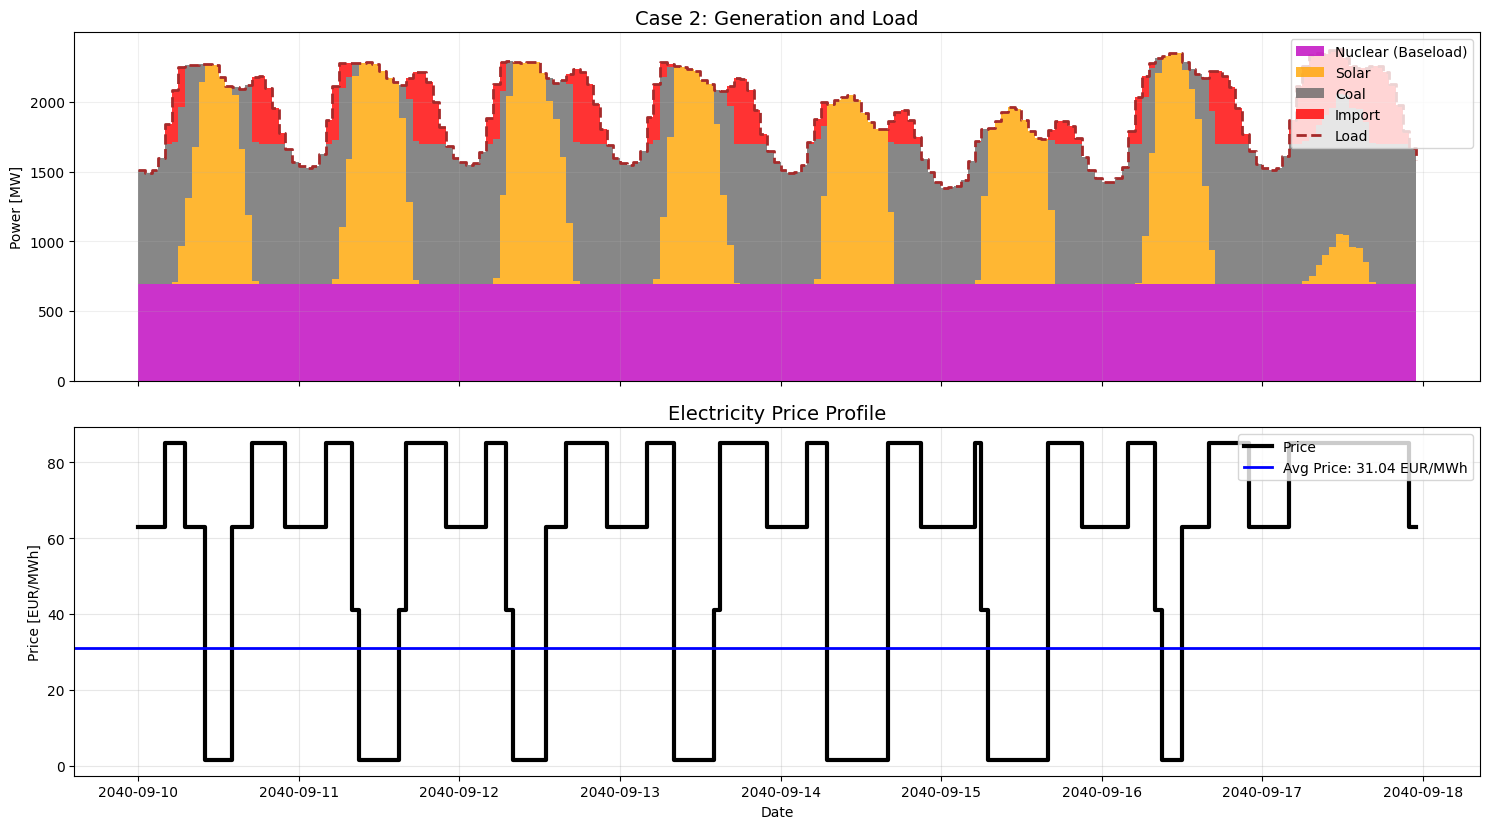

In [ ]:
import matplotlib.pyplot as plt

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(15, 8.4), sharex=True)

# Data extraction
profiles = n_c2.generators_t.p
load = n_c2.loads_t.p['Load_elec']
price = n_c2.buses_t.marginal_price['Elec']

# Calculate average marginal price for Case 2
total_cost_c2 = n_c2.objective # Assign the objective value to total_cost_c2
total_load_energy_c2 = n_c2.loads_t.p['Load_elec'].sum() # Sum of hourly load in MWh
avg_marginal_price_c2 = total_cost_c2 / total_load_energy_c2

# Create stack levels
y_stack = [
    profiles['Nuclear'],
    profiles['Solar'],
    profiles['Coal'],
    profiles['Import_elec']
]
labels = ['Nuclear (Baseload)', 'Solar', 'Coal', 'Import']
colors = ['m', 'orange', 'dimgrey', 'red']

# 1. Generation Stack (Filled Area)
axes[0].stackplot(profiles.index, y_stack, labels=labels, colors=colors, step='post', alpha=0.8)
axes[0].step(load.index, load.values, where='post', color='brown', linestyle='--', linewidth=2, label='Load')

axes[0].set_title('Case 2: Generation and Load', fontsize=14)
axes[0].set_ylabel('Power [MW]')
axes[0].legend(loc='upper right', frameon=True, facecolor='white')
axes[0].grid(True, alpha=0.2)

# 2. Price Profile
axes[1].step(price.index, price.values, where='post', color='black', linewidth=3, label='Price')
axes[1].axhline(avg_marginal_price_c2, color='blue', linestyle='-', linewidth=2, label=f'Avg Price: {avg_marginal_price_c2:,.2f} EUR/MWh')
axes[1].set_title('Electricity Price Profile', fontsize=14)
axes[1].set_ylabel('Price [EUR/MWh]')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

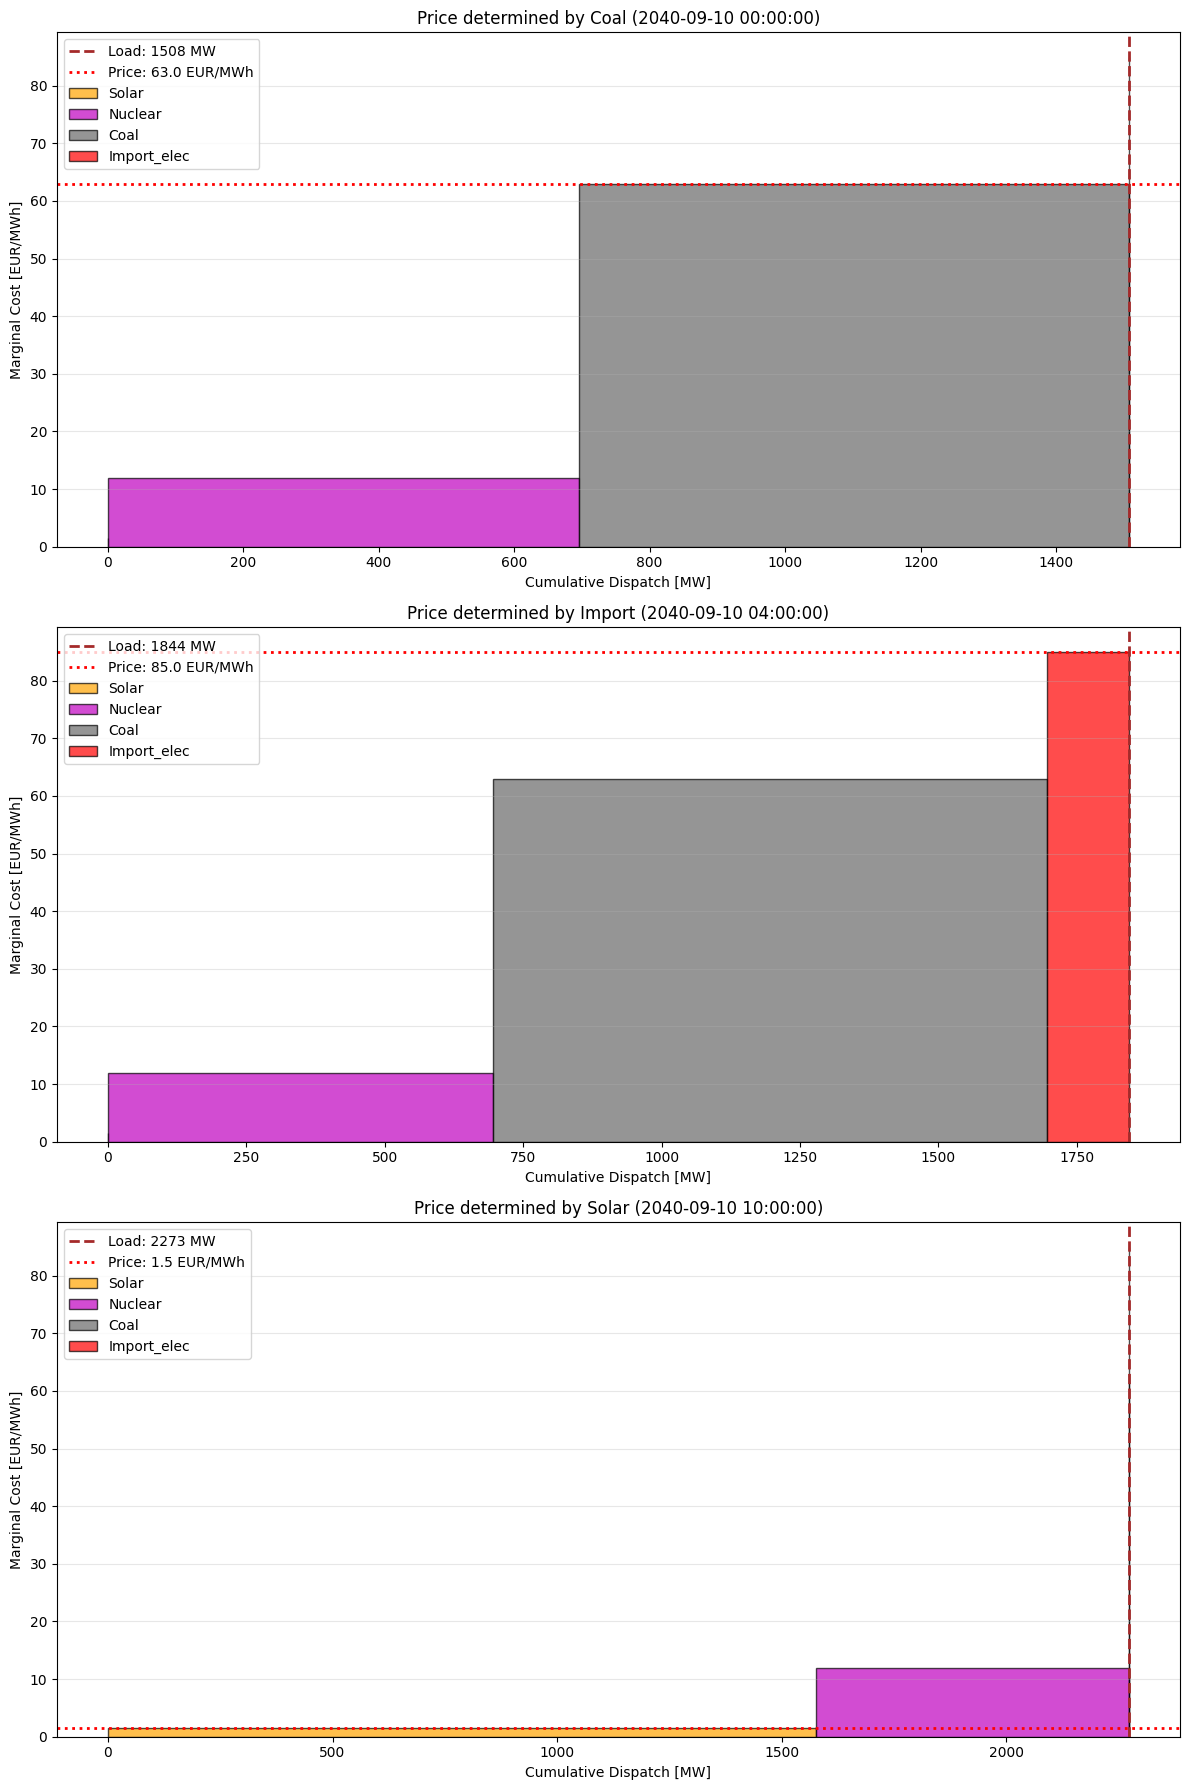

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Identify snapshots for different marginal units in Case 2
prices = n_c2.buses_t.marginal_price['Elec']

# Find representative times
coal_time = prices[prices == marginal_cost['coal']].index[0]
import_time = prices[prices == marginal_cost['import']].index[0]
solar_times = prices[prices == marginal_cost['solar']].index

# Set up the figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Coal as marginal unit
plot_merit_order_snapshot(n_c2, coal_time, axes[0], f"Price determined by Coal ({coal_time})")

# Plot 2: Import as marginal unit
plot_merit_order_snapshot(n_c2, import_time, axes[1], f"Price determined by Import ({import_time})")

# Plot 3: Solar as marginal unit (if available)
if not solar_times.empty:
    plot_merit_order_snapshot(n_c2, solar_times[0], axes[2], f"Price determined by Solar ({solar_times[0]})")
else:
    axes[2].text(0.5, 0.5, 'Solar never becomes marginal in this configuration',
                 horizontalalignment='center', verticalalignment='center', fontsize=12)
    axes[2].set_title("Price determined by Solar (No data)")

plt.tight_layout()
plt.show()

In [ ]:
# Individual cost components
nuclear_cost_c2 = (n_c2.generators_t.p['Nuclear'] * n_c2.generators.at['Nuclear', 'marginal_cost']).sum()
coal_cost_c2 = (n_c2.generators_t.p['Coal'] * n_c2.generators.at['Coal', 'marginal_cost']).sum()
solar_cost_c2 = (n_c2.generators_t.p['Solar'] * n_c2.generators.at['Solar', 'marginal_cost']).sum()
import_cost_c2 = (n_c2.generators_t.p['Import_elec'] * n_c2.generators.at['Import_elec', 'marginal_cost']).sum()

**Summary: National Mix Supported by Imports**

This case demonstrates how a more realistic generation mix, including baseload and ramp-limited units, significantly reduces system costs compared to the baseline.

*1. Demand Coverage and Dispatch Strategy:*

*   **Nuclear (Baseload)**: Set as 'must-run' (`p_min_pu=1.0`), Nuclear provides a constant supply regardless of demand fluctuations. This covers the bottom of the load curve and reduces the need for expensive alternatives.
*   **Solar (Must-take Renewable)**: Dispatched immediately after Nuclear due to its very low marginal cost (1.5 EUR/MWh).
*   **Coal (Flexible with Ramping)**: Acting as the primary balancing tool, Coal follows the remaining load. However, its flexibility is constrained by a 0.5/hr ramp rate, meaning it cannot always react instantly to sudden load changes.
*   **Imports**: Now serve as a 'peaker' or last resort, filling gaps only when the other assets are at maximum capacity or unable to ramp fast enough.

*2. Price Determination:*

The electricity price is dynamic and fluctuates based on the hourly marginal generator:
*   **Coal (63.0 EUR/MWh)**: Sets the price during most hours of the simulation.
*   **Imports (85.0 EUR/MWh)**: Sets the price during peak demand or rapid load ramps that exceed Coal's speed.
*   **Solar/Nuclear**: Would set the price at 1.5 EUR/MWh or 12.0 EUR/MWh only if they were abundant enough to meet 100% of the load.

*3. Quantitative Results (for `period_snapshots`):*

*   **Total System Cost**: `11,594,414.46` EUR (approx. **48% lower** than Case 1)
*   **Cost Breakdown**:
    *   Nuclear: `1,603,584.00` EUR
    *   Coal: `7,967,612.85` EUR
    *   Solar: `136,915.49` EUR
    *   Imports: `1,886,302.12` EUR

*Overall Takeaway:*

The introduction of cheaper baseload (Nuclear) and flexible thermal generation (Coal) drastically lowers the total system cost by displacing nearly 90% of the expensive imports used in Case 1.

**Understanding Marginal Pricing and Baseload Profitability**

In a competitive electricity market, the price is determined by the **Merit Order**.

*1. Why doesn't Nuclear set the price?*

The market price is set by the **marginal unit**—the next generator that would have to increase its output if demand rose by 1 MW.
*   Because Nuclear is already running at 100% (must-run), it cannot increase its output to meet new demand.
*   Therefore, the system must look to the next available (more expensive) generator, like **Coal** or **Imports**, to set the price.

*2. Nuclear owner profitability*

In marginal pricing, all generators that are dispatched receive the **clearing price** set by the marginal unit.

If marginal price is detemined by dispachable coal generator, nuclear owner/s making extra profit:

*   **Nuclear Cost**: 12.0 EUR/MWh
*   **Market Price (set by Coal)**: 63.0 EUR/MWh
*   **Nuclear Operational Profit (Inframarginal Rent)**: 63.0 - 12.0 = **51.0 EUR/MWh**

If solar generation is so abundant that it covers 100% of the remaining demand (after Nuclear baseload), then **Solar becomes the marginal unit**:

*   **Market Price**: 1.5 EUR/MWh (Solar's marginal cost).
*   **Nuclear Revenue**: 1.5 EUR/MWh.
*   **Nuclear Operating Profit**: 1.5 - 12.0 = **-10.5 EUR/MWh** (A Loss).

*3. Why does this happen?*
* **Inflexibility**: Because Nuclear is 'must-run', it is forced to sell at whatever the market price is, even if that price is below its operating cost.
* **Renewable Impact**: High penetration of renewables with near-zero marginal costs frequently pushes expensive thermal or nuclear plants into 'negative' or very low-profit territory during sunny or windy hours.

### Case 3 - Adding Storage

In [ ]:
# CASE 3 - Integrating Storage
# Initialize Network
n_c3 = pypsa.Network()
n_c3.set_snapshots(period_snapshots)
n_c3.add("Carrier", "AC")
n_c3.add("Bus", "Elec", carrier="AC")

# Add Load
n_c3.add("Load", "Load_elec", bus="Elec", p_set=input_profiles.loc[n_c3.snapshots, 'elec_profile_2040_scaled'])

# Add Generators
n_c3.add("Generator", "Nuclear", bus="Elec", p_nom=elec_generators['Nuclear']['p_nom'], marginal_cost=marginal_cost['nuclear'], p_min_pu=1.0, overwrite=True)
n_c3.add("Generator", "Coal", bus="Elec", p_nom=1000, marginal_cost=marginal_cost['coal'], ramp_limit_up=0.5, ramp_limit_down=0.5, overwrite=True)
n_c3.add("Generator", "Solar", bus="Elec", p_nom=elec_generators['Solar']['p_nom'], marginal_cost=marginal_cost['solar'], p_max_pu=input_profiles.loc[n_c3.snapshots, 'df_solar'].values, overwrite=True)
n_c3.add("Generator", "Import_elec", bus="Elec", p_nom=5000.0, marginal_cost=marginal_cost['import'], overwrite=True)

# Add Storage Unit
n_c3.add("StorageUnit", "Storage",
    bus="Elec",
    p_nom=storage_parameters['power'],
    max_hours=storage_parameters['capacity'] / storage_parameters['power'],
    efficiency_store=storage_parameters['charging_efficiency'],
    efficiency_dispatch=storage_parameters['discharging_efficiency'],
    cyclic_state_of_charge=True)

# Optimize
result_c3 = n_c3.optimize(solver_name='highs', include_objective_constant=False)

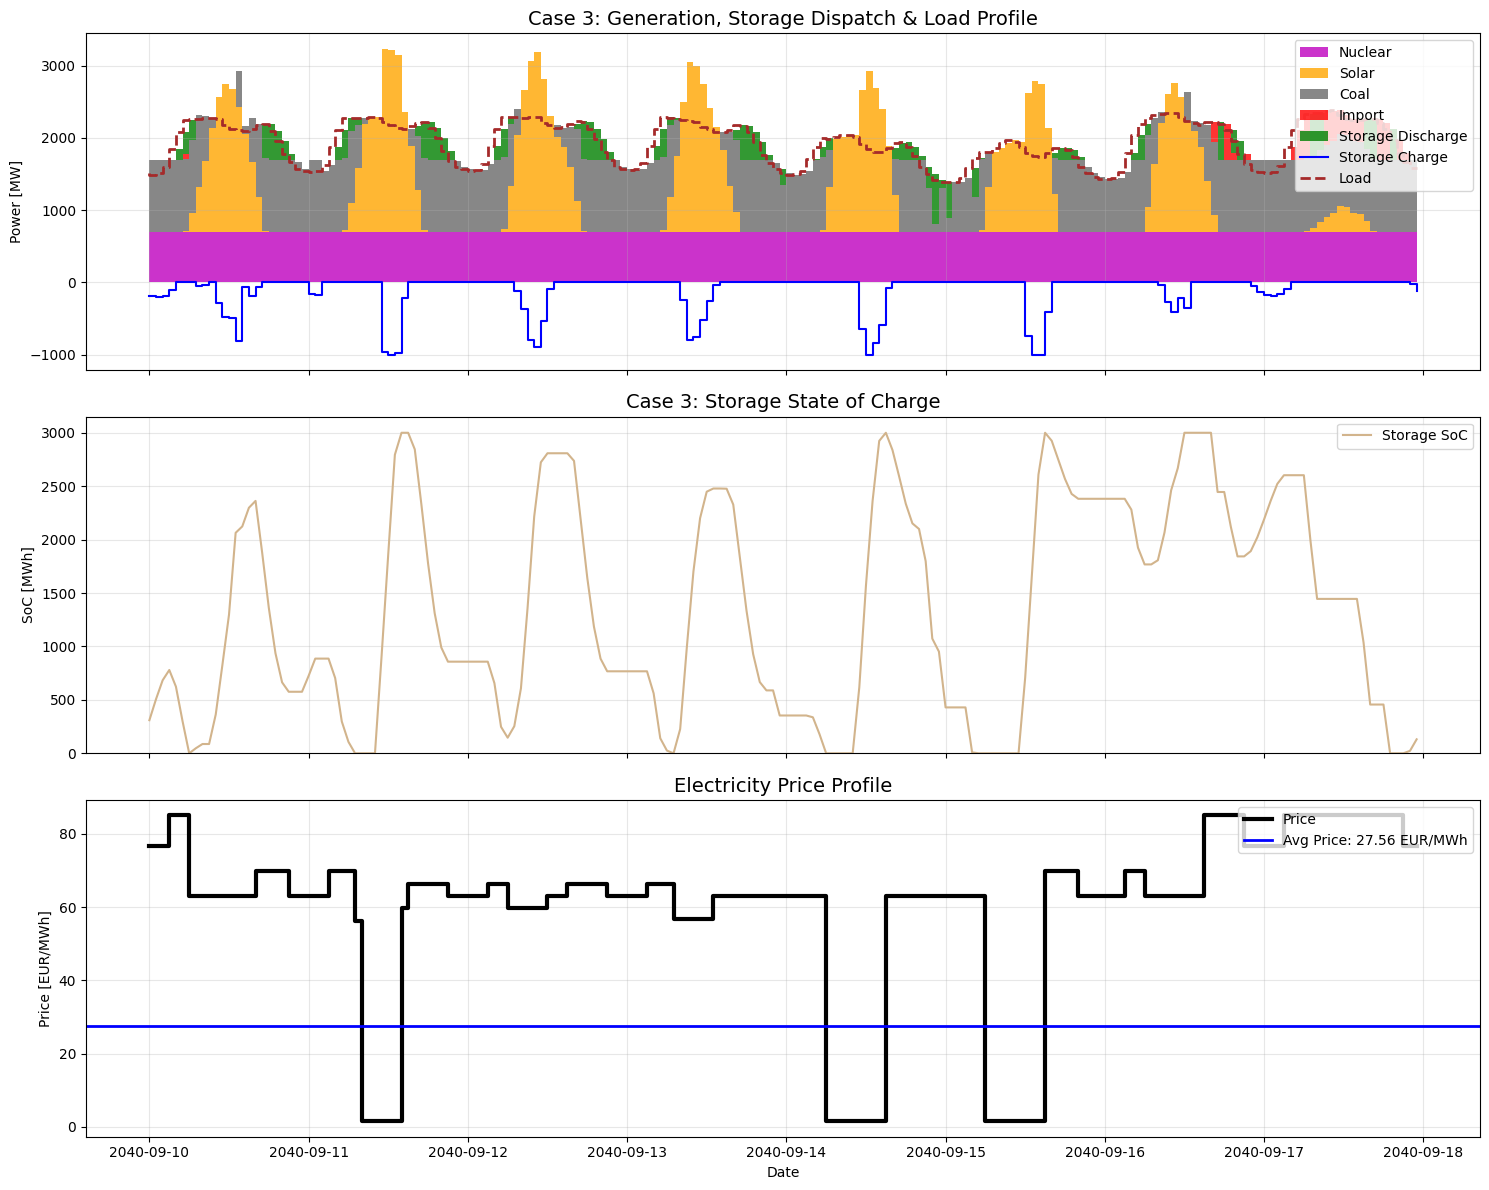

In [ ]:
# Step 6: Plotting Results
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Extract data for stacking
p_gen = n_c3.generators_t.p
p_storage = n_c3.storage_units_t.p['Storage']
soc = n_c3.storage_units_t.state_of_charge['Storage']

# Calculate average marginal price for Case 3
total_cost_c3 = n_c3.objective
total_load_energy_c3 = n_c3.loads_t.p['Load_elec'].sum()
avg_marginal_price_c3 = total_cost_c3 / total_load_energy_c3

# Prepare the stack components
y_stack_gen = [
    p_gen['Nuclear'].values,
    p_gen['Solar'].values,
    p_gen['Coal'].values,
    p_gen['Import_elec'].values,
    p_storage.clip(lower=0).values
]
labels_gen = ['Nuclear', 'Solar', 'Coal', 'Import', 'Storage Discharge']
colors_gen = ['m', 'orange', 'dimgrey', 'red', 'green']

# 1. Generation/Load Dispatch
axes[0].stackplot(n_c3.snapshots, y_stack_gen, labels=labels_gen, colors=colors_gen, step='post', alpha=0.8)
axes[0].step(n_c3.snapshots, p_storage.clip(upper=0).values, color='blue', label='Storage Charge', where='post')
axes[0].step(n_c3.snapshots, n_c3.loads_t.p['Load_elec'].values, color='brown', linestyle='--', linewidth=2, label='Load')
axes[0].set_title('Case 3: Generation, Storage Dispatch & Load Profile', fontsize=14)
axes[0].set_ylabel('Power [MW]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. State of Charge (SoC)
axes[1].plot(n_c3.snapshots, soc.values, color='tan', linestyle='-', label='Storage SoC')
axes[1].set_title('Case 3: Storage State of Charge', fontsize=14)
axes[1].set_ylabel('SoC [MWh]')
axes[1].set_ylim(0, n_c3.storage_units.at['Storage', 'p_nom'] * n_c3.storage_units.at['Storage', 'max_hours'] * 1.05)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# 3. Price Profile
axes[2].step(n_c3.snapshots, n_c3.buses_t.marginal_price['Elec'], color='black', linewidth=3, label='Price')
axes[2].axhline(avg_marginal_price_c3, color='blue', linestyle='-', linewidth=2, label=f'Avg Price: {avg_marginal_price_c3:,.2f} EUR/MWh')
axes[2].set_title('Electricity Price Profile', fontsize=14)
axes[2].set_ylabel('Price [EUR/MWh]')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

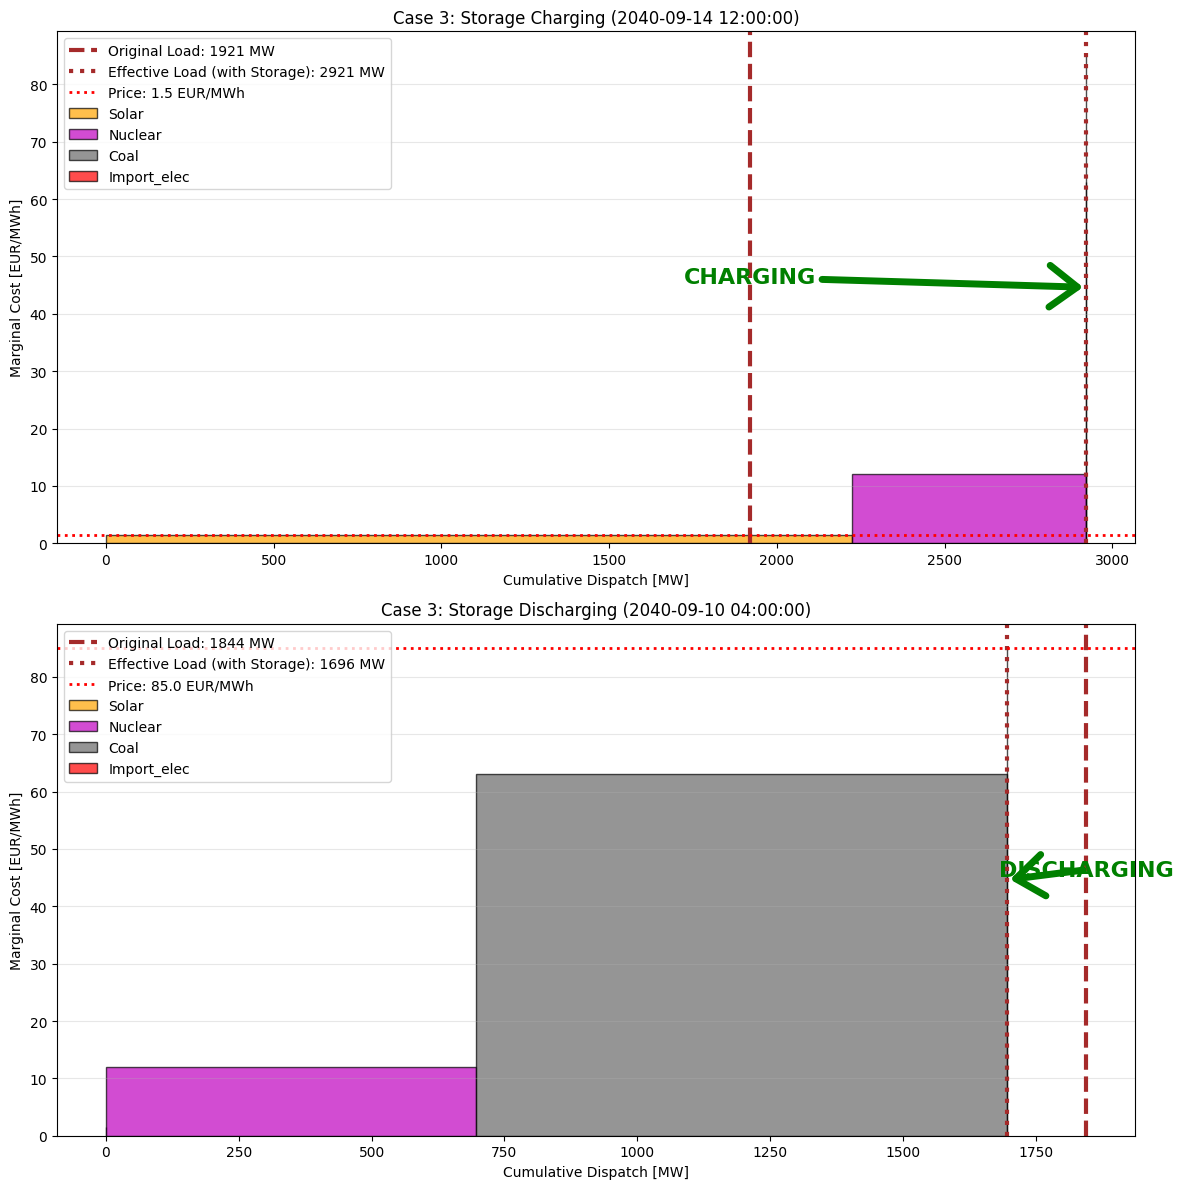

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Identifiers for snapshots ---
prices_c3 = n_c3.buses_t.marginal_price['Elec']
specific_charging_time = pd.Timestamp('2040-09-14 12:00:00')
charging_time = specific_charging_time if specific_charging_time in prices_c3.index else prices_c3.index[0]
discharging_time = prices_c3[prices_c3 == marginal_cost['import']].index[0]

def plot_merit_order_snapshot_c3(network, snapshot, ax, title):
    gen_data = pd.DataFrame({
        'marginal_cost': network.generators.marginal_cost,
        'dispatch': network.generators_t.p.loc[snapshot],
        'p_nom': network.generators.p_nom
    }).sort_values(by='marginal_cost')

    gen_data['cum_dispatch'] = gen_data['dispatch'].cumsum()
    gen_data['prev_cum_dispatch'] = gen_data['cum_dispatch'].shift(1, fill_value=0)

    color_map = {'Solar': 'orange', 'Nuclear': 'm', 'Coal': 'dimgrey', 'Import_elec': 'red'}

    for name in gen_data.index:
        row = gen_data.loc[name]
        ax.bar(row['prev_cum_dispatch'], row['marginal_cost'],
               width=row['dispatch'], align='edge',
               label=name, color=color_map.get(name, 'black'), alpha=0.7, edgecolor='black')

    original_load = network.loads_t.p_set.loc[snapshot, 'Load_elec']
    storage_dispatch = network.storage_units_t.p.loc[snapshot, 'Storage']
    effective_load = original_load - storage_dispatch
    system_price = network.buses_t.marginal_price.at[snapshot, 'Elec']

    ax.axvline(original_load, color='brown', linestyle='--', linewidth=3, label=f'Original Load: {original_load:.0f} MW')
    ax.axvline(effective_load, color='brown', linestyle=':', linewidth=3, label=f'Effective Load (with Storage): {effective_load:.0f} MW')
    ax.axhline(system_price, color='red', linestyle=':', linewidth=2, label=f'Price: {system_price} EUR/MWh')

    y_arrow = ax.get_ylim()[1] * 0.5
    arrow_props = dict(arrowstyle='->, head_width=0.6, head_length=0.8', color='green', lw=5, mutation_scale=25)

    if storage_dispatch < 0:
        ax.annotate('CHARGING', xy=(effective_load, y_arrow), xytext=(original_load, y_arrow),
                    arrowprops=arrow_props,
                    color='green', fontweight='bold', fontsize=16, ha='center', va='bottom')
    elif storage_dispatch > 0:
        ax.annotate('DISCHARGING', xy=(effective_load, y_arrow), xytext=(original_load, y_arrow),
                    arrowprops=arrow_props,
                    color='green', fontweight='bold', fontsize=16, ha='center', va='bottom')

    ax.set_title(title)
    ax.set_xlabel('Cumulative Dispatch [MW]')
    ax.set_ylabel('Marginal Cost [EUR/MWh]')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
plot_merit_order_snapshot_c3(n_c3, charging_time, ax1, f'Case 3: Storage Charging ({charging_time})')
plot_merit_order_snapshot_c3(n_c3, discharging_time, ax2, f'Case 3: Storage Discharging ({discharging_time})')
plt.tight_layout()
plt.show()

Found reduction at 2040-09-13 15:00:00
Price without battery: 85.00 EUR/MWh
Price with battery: 63.00 EUR/MWh
Battery discharging: 1.76 MW


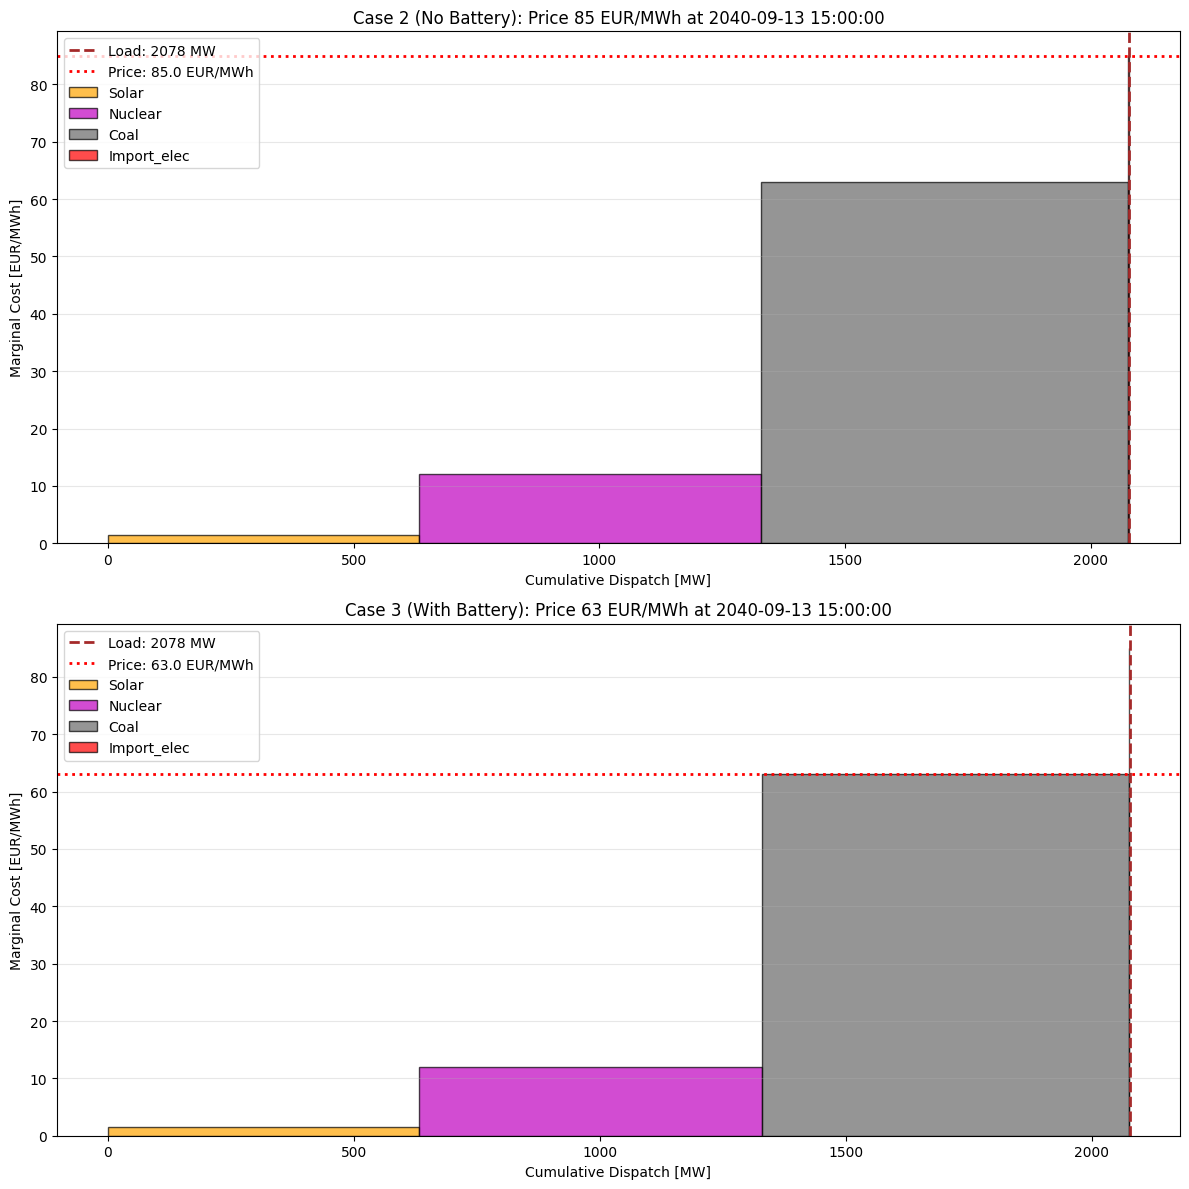

In [ ]:
import matplotlib.pyplot as plt

# Identify snapshots where price dropped from 85 to 63 due to battery
price_c2 = n_c2.buses_t.marginal_price['Elec']
price_c3 = n_c3.buses_t.marginal_price['Elec']

reduction_snapshots = price_c3[(price_c2 == 85) & (price_c3 == 63)].index

if not reduction_snapshots.empty:
    target_time = reduction_snapshots[0]
    battery_dispatch = n_c3.storage_units_t.p.at[target_time, 'Storage']

    print(f"Found reduction at {target_time}")
    print(f"Price without battery: {price_c2[target_time]:.2f} EUR/MWh")
    print(f"Price with battery: {price_c3[target_time]:.2f} EUR/MWh")
    print(f"Battery discharging: {battery_dispatch:.2f} MW")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    plot_merit_order_snapshot(n_c2, target_time, ax1, f"Case 2 (No Battery): Price 85 EUR/MWh at {target_time}")
    plot_merit_order_snapshot(n_c3, target_time, ax2, f"Case 3 (With Battery): Price 63 EUR/MWh at {target_time}")
    plt.tight_layout()
    plt.show()
else:
    print("No snapshots found where the price was reduced exactly from 85 to 63. Let's check the price ranges.")

In [ ]:

# Individual cost components
nuclear_cost_c3 = (n_c3.generators_t.p['Nuclear'] * n_c3.generators.at['Nuclear', 'marginal_cost']).sum()
coal_cost_c3 = (n_c3.generators_t.p['Coal'] * n_c3.generators.at['Coal', 'marginal_cost']).sum()
solar_cost_c3 = (n_c3.generators_t.p['Solar'] * n_c3.generators.at['Solar', 'marginal_cost']).sum()
import_cost_c3 = (n_c3.generators_t.p['Import_elec'] * n_c3.generators.at['Import_elec', 'marginal_cost']).sum()

# Get storage dispatch data
storage_dispatch = n_c3.storage_units_t.p['Storage']
storage_prices = n_c3.buses_t.marginal_price['Elec']

revenue_from_discharge = (storage_dispatch.clip(lower=0) * storage_prices).sum()
cost_of_charge = (storage_dispatch.clip(upper=0).abs() * storage_prices).sum()
storage_net_income = revenue_from_discharge - cost_of_charge


**Summary: Generators, Import and Storage**

This case demonstrates the impact of energy storage on system costs and price stability by decoupling the timing of generation and consumption.

*1. Demand Coverage and Dispatch Strategy:*

*   **Nuclear & Solar**: Continue to serve as the primary low-cost energy sources. However, solar utilization is improved as the storage can capture excess midday production.
*   **Energy Storage**: Acts as a price-responsive load (charging when prices are low, typically during solar peaks or low-demand coal hours) and a peaking generator (discharging when prices are high, displacing imports).
*   **Coal**: Dispatched more efficiently to both meet load and charge the storage when it is cheaper than the alternative (Imports).
*   **Imports**: Usage is drastically reduced compared to Case 2, as stored energy from cheaper hours is used to cover peaks.

*2. Price Determination:*

*   **Price Arbitrage**: Storage 'shaves' the peaks and 'fills' the valleys of the price profile.
*   **Solar/Coal as Marginal**: Storage often sets the price floor by charging when solar or coal are marginal, preventing prices from dropping further and capturing low-cost energy.
*   **Reduced Peak Prices**: By discharging during high-load periods, storage prevents the expensive Import generator from becoming the marginal unit as frequently.

*3. Quantitative Results (for `period_snapshots`):*

*   **Total System Cost**: `10,295,475.66` EUR (approx. **11% lower** than Case 2 and **54% lower** than Case 1)
*   **Average Marginal Price**: `27.56` EUR/MWh (compared to `31.04` in Case 2)
*   **Storage Net Income (Arbitrage Value)**: `596,341.12` EUR
*   **Import Cost Reduction**: Imports decreased from `1,886,302` EUR (Case 2) to `479,492` EUR (Case 3).

*Overall Takeaway:*

Case 3 illustrates that storage is a powerful tool for system optimization. It reduces total costs not by creating energy, but by shifting it in time to ensure that the most expensive generators are used as little as possible.

**Mechanisms of Storage Influence on Marginal Pricing**

Energy storage stabilizes the electricity market by decoupling the timing of generation and consumption. By shifting energy across time, it modifies the **Merit Order** in real-time.

*1. The Concept of 'Effective Load'*

To understand the graphs, we compare the **Original Load** (actual consumer demand) with the **Effective Load** (what the generators actually see):
*   **Charging**: Effective Load = Original Load + Storage Demand. This shifts the demand line to the **right** on the merit order curve.
*   **Discharging**: Effective Load = Original Load - Storage Supply. This shifts the demand line to the **left** on the merit order curve.

*2. Key Economic Influences*

*   **Peak Shaving (Price Capping)**: During high-demand periods, storage discharges to reduce the *Effective Load*. This prevents the system from needing expensive 'Imports' (85 EUR/MWh), keeping the marginal price at the 'Coal' level (63 EUR/MWh).
*   **Valley Filling (Price Flooring)**: During solar peaks, storage charges to increase the *Effective Load*. This prevents the price from dropping to the 'Solar' level (1.5 EUR/MWh) by creating additional demand at a higher price point (e.g., Coal).
*   **System Efficiency**: High-efficiency storage allows for better utilization of low-cost, inflexible generators like Nuclear.

*3. Storage Revenue Analysis*

The storage unit generates value through **Price Arbitrage** (buying low, selling high). Based on our simulation:
*   **Total Revenue (Discharging)**: 1,309,634.18 EUR
*   **Total Cost (Charging)**: 713,293.07 EUR
*   **Net Income (Arbitrage Value)**: **596,341.12 EUR**

*4. Why Prices Fluctuate Around 63 EUR/MWh (The Efficiency Gap)*

The price isn't always exactly 63.0 EUR, but fluctuates slightly (e.g., 66.3 or 59.8). This is due to **Round-Trip Efficiency (95%)**:
*   The optimizer only moves energy if the price difference between charging and discharging is large enough to cover the **5% energy loss**.
*   This creates a 'deadband' or a price spread where the storage unit is indifferent, causing the marginal price to reflect the marginal generator adjusted for these conversion losses.

*5. Real-World Snapshots*

*   **Charging Snapshot (Sep 14, 12:00)**: Solar is abundant. Storage increases the *Effective Load* (dotted line moves right). Even though Solar is available at 1.5 EUR, the storage demand might keep a more expensive generator marginal to ensure it fills its capacity for later use.
*   **Discharging Snapshot (Sep 11, Evening)**: Demand is peaking. Storage supply reduces the *Effective Load* (dotted line moves left). This displacement of high-cost imports is what causes the 'cap' on system prices.



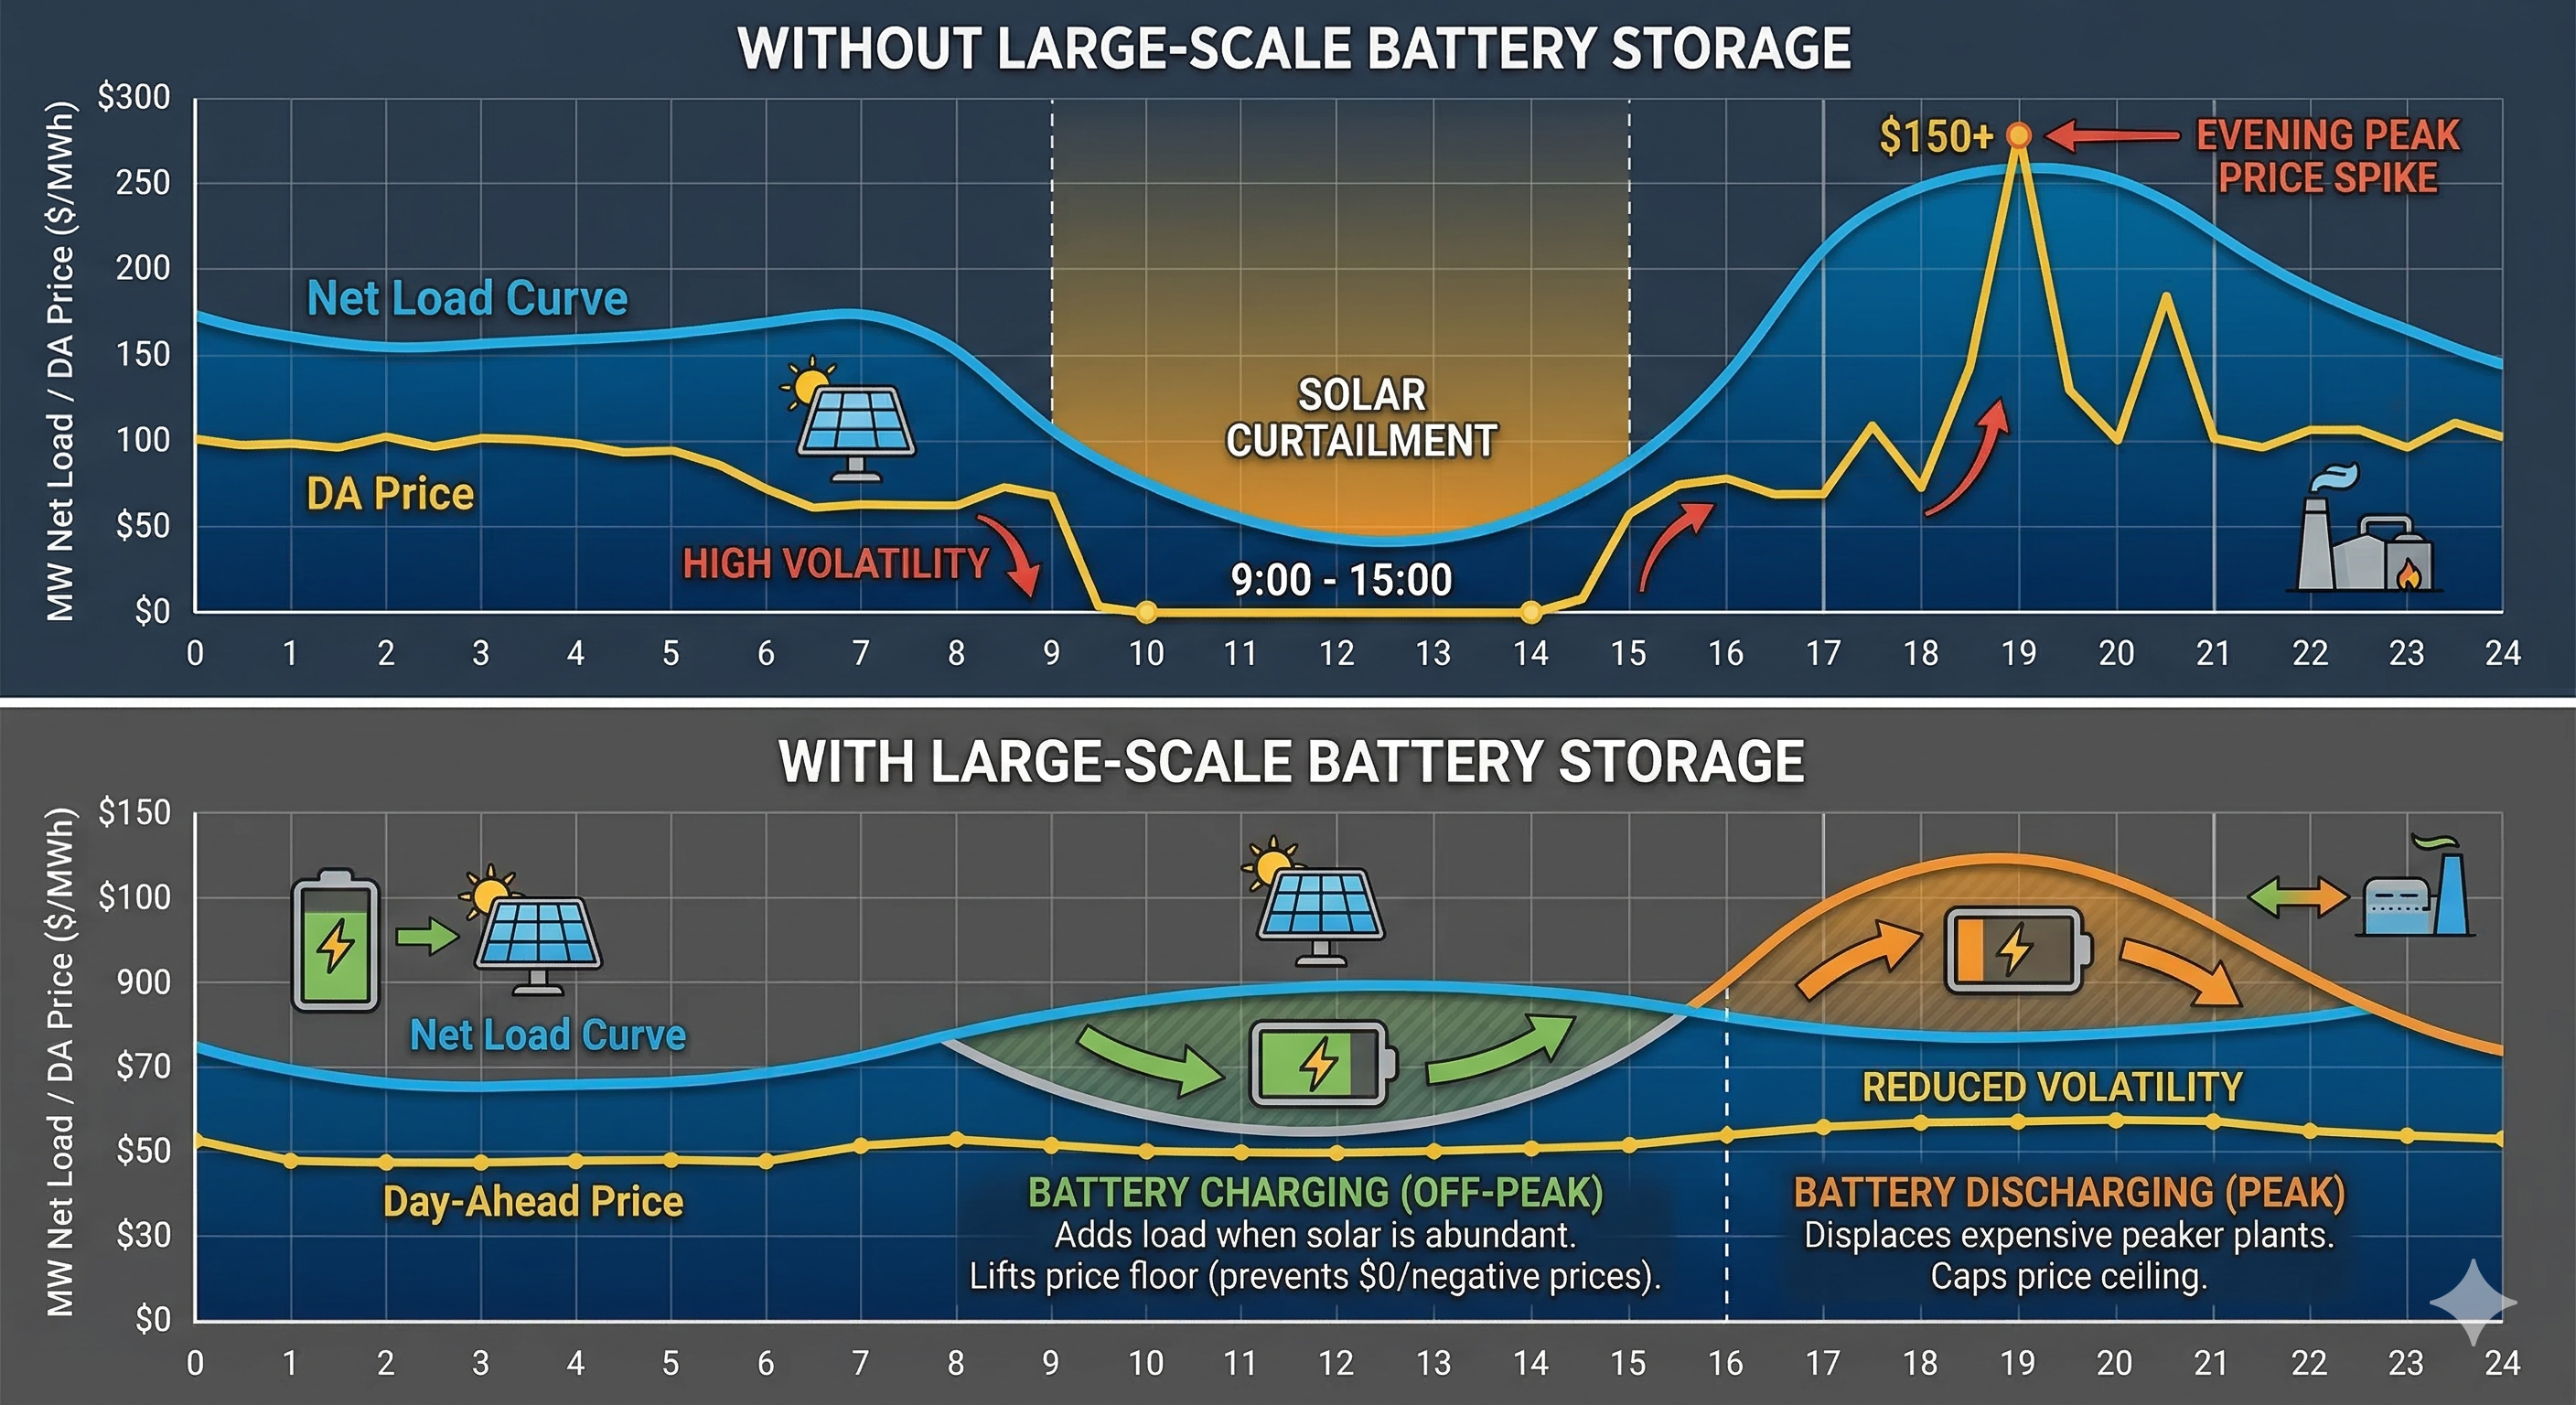

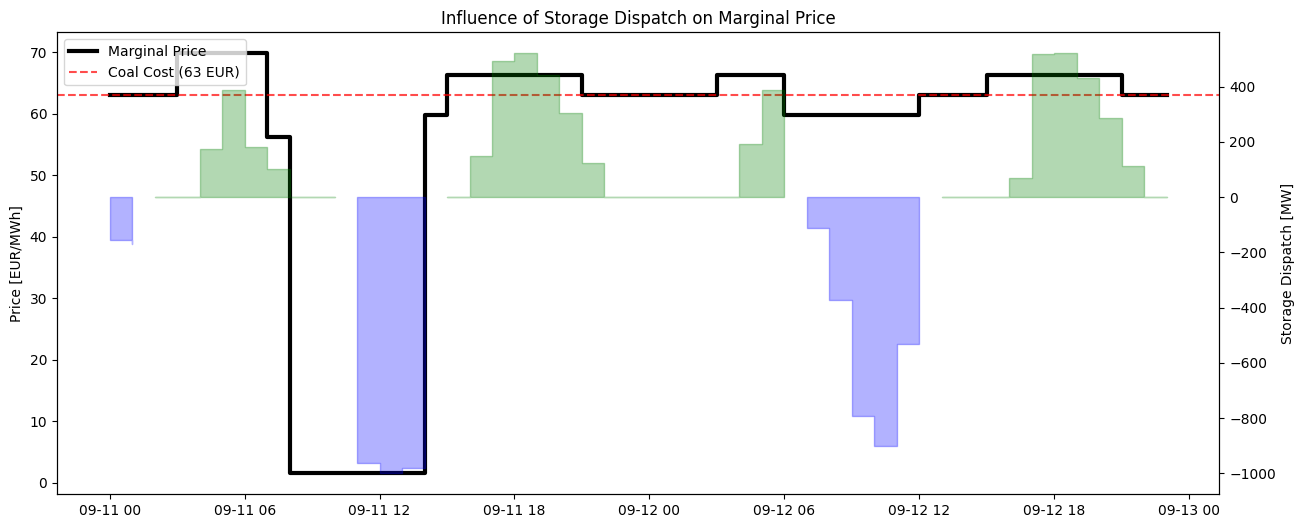

In [ ]:
# Re-plotting the Zoom View
zoom_snapshots = n_c3.snapshots[24:72]
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.step(zoom_snapshots, n_c3.buses_t.marginal_price.loc[zoom_snapshots, 'Elec'], color='black', lw=3, label='Marginal Price')
ax1.axhline(63, color='red', linestyle='--', alpha=0.7, label='Coal Cost (63 EUR)')
ax1.set_ylabel('Price [EUR/MWh]')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.fill_between(zoom_snapshots, 0, n_c3.storage_units_t.p.loc[zoom_snapshots, 'Storage'],
                 where=(n_c3.storage_units_t.p.loc[zoom_snapshots, 'Storage'] >= 0), color='green', alpha=0.3, step='post', label='Discharging')
ax2.fill_between(zoom_snapshots, 0, n_c3.storage_units_t.p.loc[zoom_snapshots, 'Storage'],
                 where=(n_c3.storage_units_t.p.loc[zoom_snapshots, 'Storage'] < 0), color='blue', alpha=0.3, step='post', label='Charging')
ax2.set_ylabel('Storage Dispatch [MW]')

plt.title('Influence of Storage Dispatch on Marginal Price')
plt.show()

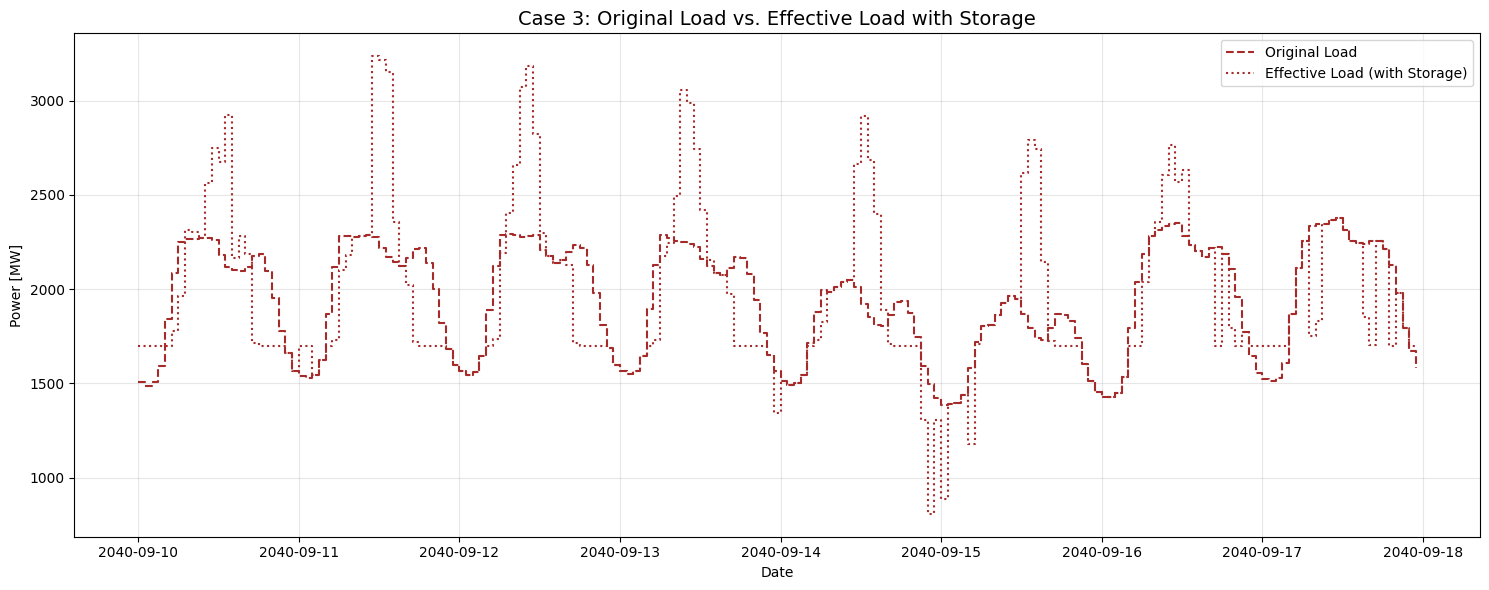

In [ ]:
# Get storage data from Case 3
original_load_c3 = n_c3.loads_t.p['Load_elec']
storage_dispatch_c3 = n_c3.storage_units_t.p['Storage']
effective_load_c3 = original_load_c3 - storage_dispatch_c3

plt.figure(figsize=(15, 6))
plt.step(original_load_c3.index, original_load_c3.values, where='post', color='brown', linestyle='--', label='Original Load')
plt.step(effective_load_c3.index, effective_load_c3.values, where='post', color='brown', linestyle='dotted', label='Effective Load (with Storage)')
plt.title('Case 3: Original Load vs. Effective Load with Storage', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Power [MW]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Case 4 - Full Hydrogen Arbitrage Loop

This case evaluates the integration of a Hydrogen Energy Storage System (HESS) into the power grid. It includes:
*   **Electrolyzer:** Converts surplus/cheap electricity into hydrogen.
*   **H2 Store:** Provides large-scale, long-duration energy storage.
*   **CCGT:** Converts stored hydrogen back into electricity during peak demand or high-price periods.


In [ ]:
# CASE 4 - Generators and Hydrogen Set
# Initialize Network
n_c4 = pypsa.Network()
n_c4.set_snapshots(period_snapshots)
n_c4.add("Carrier", "AC")
n_c4.add("Carrier", "hydrogen")

# Add Buses
n_c4.add("Bus", "Elec", carrier="AC")
n_c4.add("Bus", "H2", carrier="hydrogen")

# Add Load
n_c4.add("Load", "Load_elec", bus="Elec", p_set=input_profiles.loc[n_c4.snapshots, 'elec_profile_2040_scaled'])

# Add Generators
n_c4.add("Generator", "Nuclear", bus="Elec", p_nom=elec_generators['Nuclear']['p_nom'], marginal_cost=marginal_cost['nuclear'], p_min_pu=1.0)
n_c4.add("Generator", "Coal", bus="Elec", p_nom=1000, marginal_cost=marginal_cost['coal'], ramp_limit_up=0.5, ramp_limit_down=0.5)
n_c4.add("Generator", "Solar", bus="Elec", p_nom=elec_generators['Solar']['p_nom'], marginal_cost=marginal_cost['solar'], p_max_pu=input_profiles.loc[n_c4.snapshots, 'df_solar'].values)
n_c4.add("Generator", "Import_elec", bus="Elec", p_nom=5000.0, marginal_cost=marginal_cost['import'])

# Add Hydrogen Components
n_c4.add("Link", "Electrolyzer", bus0="Elec", bus1="H2", p_nom=1200, efficiency=0.70)
n_c4.add("Link", "CCGT", bus0="H2", bus1="Elec", p_nom=1200, efficiency=0.60, marginal_cost=0.0)

# 3. Hydrogen Storage
# Set e_initial to 5000 and e_cyclic to False so e_initial is respected
n_c4.add("Store", "H2_Store", bus="H2", e_nom=10000, e_initial=5000, e_cyclic=False)

# Manually enforce cyclic behavior: final state must be 5000 MWh
# We set e_min_pu for the final snapshot to 5000 / e_nom (0.25)
n_c4.stores_t.e_min_pu = pd.DataFrame(0.0, index=n_c4.snapshots, columns=["H2_Store"])
n_c4.stores_t.e_min_pu.loc[n_c4.snapshots[-1], "H2_Store"] = 5000 / 20000

# Optimize
result_c4 = n_c4.optimize(solver_name='highs', include_objective_constant=False)
print(result_c4)

('ok', 'optimal')


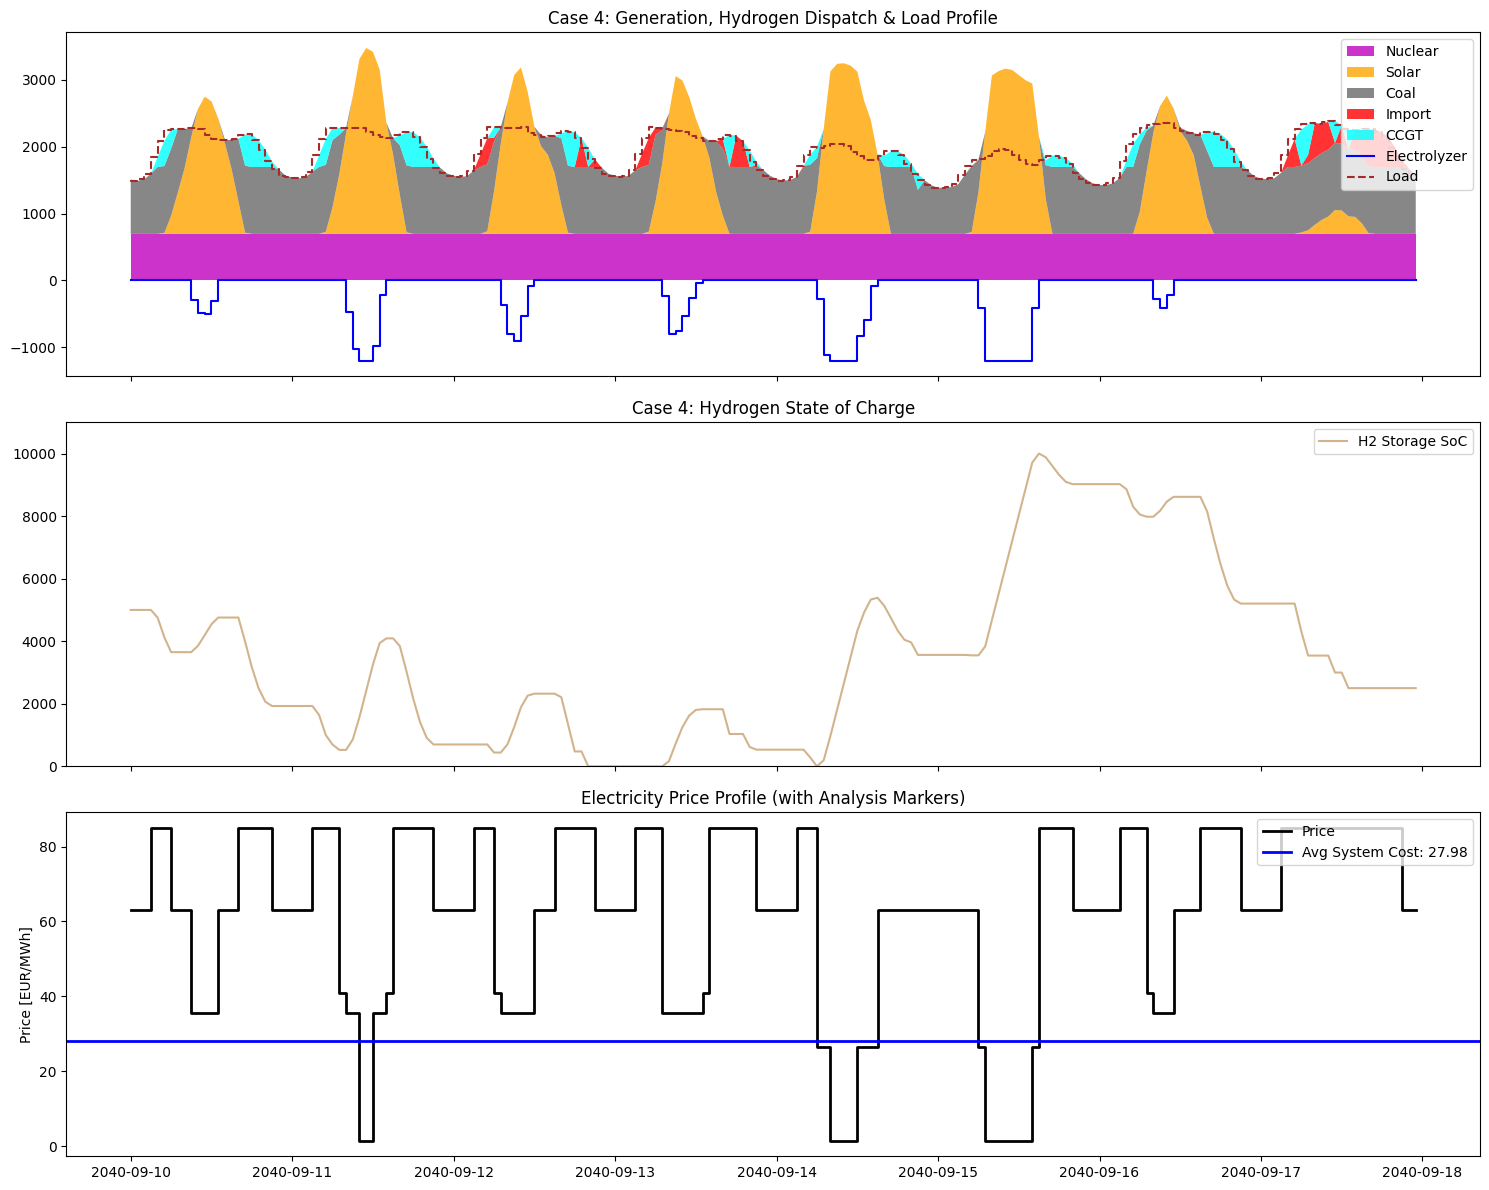

In [ ]:
# Step 6: Plotting Results for Case 4 (Updated with Example Markers)
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Extract data for stacking
p_gen = n_c4.generators_t.p
p_ccgt = -n_c4.links_t.p1['CCGT']
p_electrolyzer = n_c4.links_t.p0['Electrolyzer']
soc_h2 = n_c4.stores_t.e['H2_Store']

# Calculate average system cost
total_cost_c4 = n_c4.objective
total_load_energy_c4 = n_c4.loads_t.p['Load_elec'].sum()
avg_system_cost_c4 = total_cost_c4 / total_load_energy_c4

# 1. Generation/Load Dispatch
y_stack_gen = [p_gen['Nuclear'].values, p_gen['Solar'].values, p_gen['Coal'].values, p_gen['Import_elec'].values, p_ccgt.values]
axes[0].stackplot(n_c4.snapshots, y_stack_gen, labels=['Nuclear', 'Solar', 'Coal', 'Import', 'CCGT'], colors=['m', 'orange', 'dimgrey', 'red', 'cyan'], alpha=0.8)
axes[0].step(n_c4.snapshots, -p_electrolyzer.values, color='blue', label='Electrolyzer')
axes[0].step(n_c4.snapshots, n_c4.loads_t.p['Load_elec'].values, color='brown', linestyle='--', label='Load')
axes[0].set_title('Case 4: Generation, Hydrogen Dispatch & Load Profile')
axes[0].legend(loc='upper right')

# 2. State of Charge (SoC)
axes[1].plot(n_c4.snapshots, soc_h2.values, color='tan', label='H2 Storage SoC')
axes[1].set_title('Case 4: Hydrogen State of Charge')
axes[1].set_ylim(0, 11000)
axes[1].legend(loc='upper right')

# 3. Price Profile with vertical markers for analysis examples
axes[2].step(n_c4.snapshots, n_c4.buses_t.marginal_price['Elec'], color='black', linewidth=2, label='Price')
axes[2].axhline(avg_system_cost_c4, color='blue', linestyle='-', linewidth=2, label=f'Avg System Cost: {avg_system_cost_c4:,.2f}')

# Add vertical lines for the snapshots used in merit order analysis
# Assuming snap_h2_charge and snap_h2_discharge are defined in the environment
try:
    axes[2].axvline(snap_h2_charge, color='blue', linestyle='--', alpha=0.7, label='Ex 1: Electrolyzer Snapshot')
    axes[2].axvline(snap_h2_discharge, color='cyan', linestyle='--', alpha=0.7, label='Ex 2: CCGT Snapshot')
except NameError:
    pass # If the example snapshots haven't been defined yet

axes[2].set_title('Electricity Price Profile (with Analysis Markers)')
axes[2].set_ylabel('Price [EUR/MWh]')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

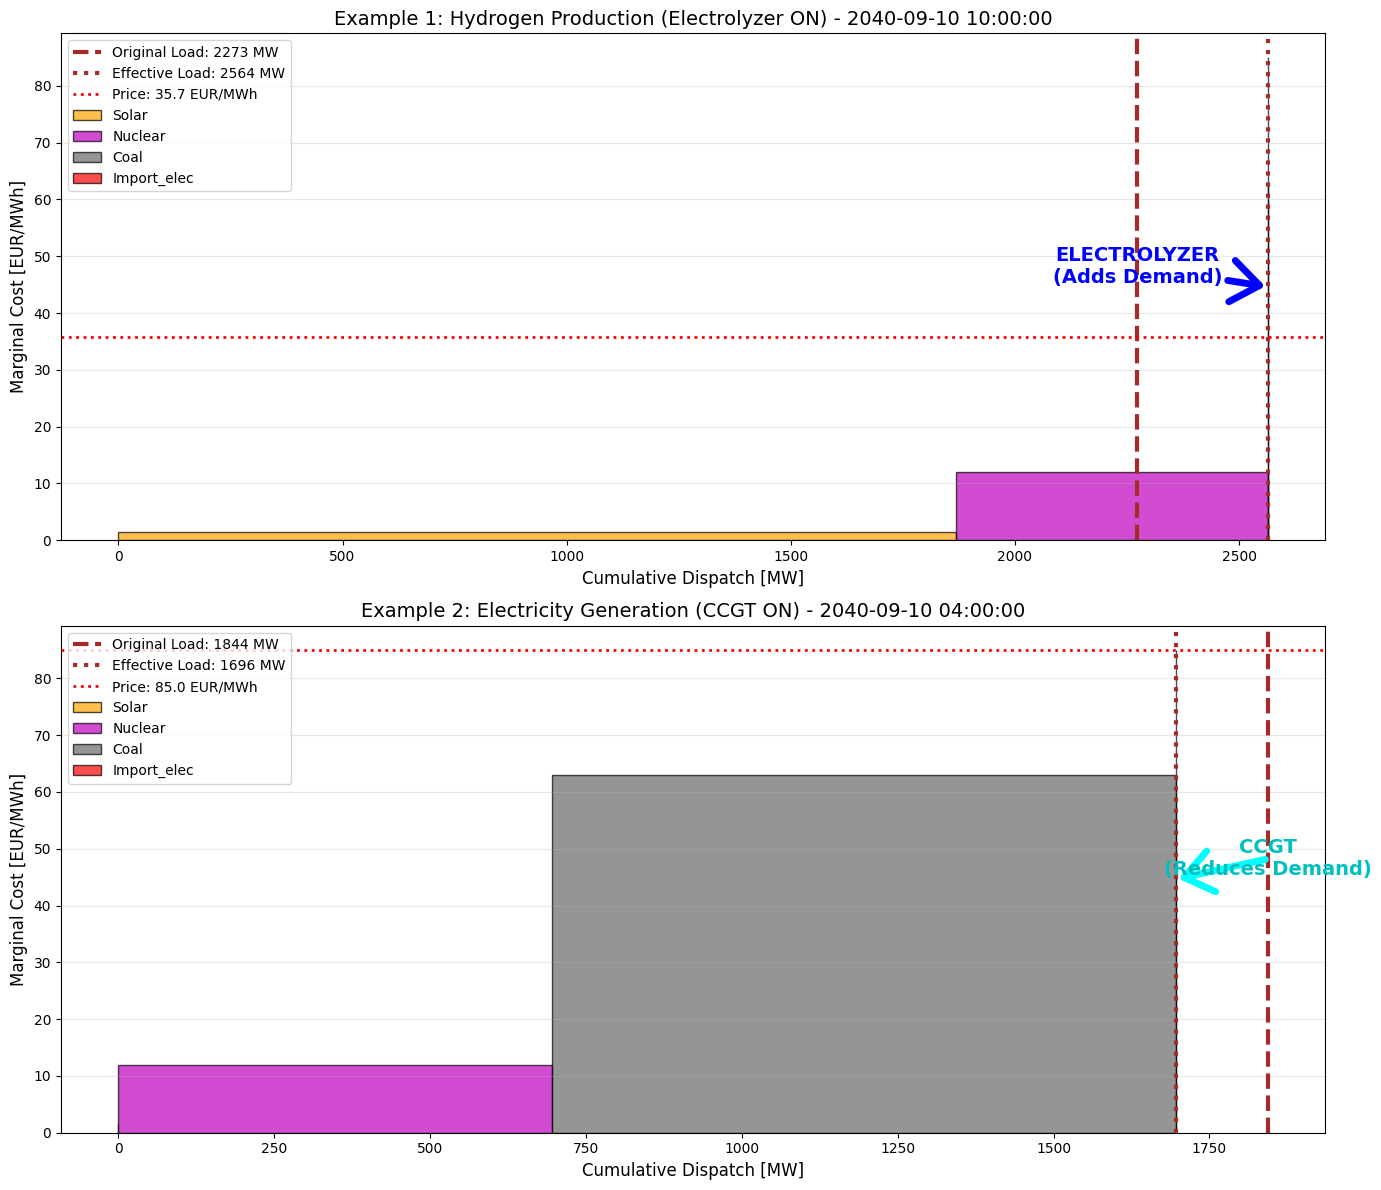

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Identify snapshots for the requested examples
prices_c4 = n_c4.buses_t.marginal_price['Elec']
p_electrolyzer = n_c4.links_t.p0['Electrolyzer']
p_ccgt = -n_c4.links_t.p1['CCGT']

# 1. Price < 40 EUR/MWh and electrolyzer is running
valid_electrolyzer = prices_c4[(p_electrolyzer > 100) & (prices_c4 < 40)].index
snap_h2_charge = valid_electrolyzer[0] if len(valid_electrolyzer) > 0 else prices_c4.index[0]

# 2. CCGT is generating electricity
valid_ccgt = prices_c4[p_ccgt > 100].index
snap_h2_discharge = valid_ccgt[0] if len(valid_ccgt) > 0 else prices_c4.index[0]

def plot_merit_order_snapshot_c4(network, snapshot, ax, title):
    # Get generator dispatch and marginal costs
    gen_data = pd.DataFrame({
        'marginal_cost': network.generators.marginal_cost,
        'dispatch': network.generators_t.p.loc[snapshot],
        'p_nom': network.generators.p_nom
    }).sort_values(by='marginal_cost')

    # Calculate cumulative dispatch for plotting bars
    gen_data['cum_dispatch'] = gen_data['dispatch'].cumsum()
    gen_data['prev_cum_dispatch'] = gen_data['cum_dispatch'].shift(1, fill_value=0)

    color_map = {'Solar': 'orange', 'Nuclear': 'm', 'Coal': 'dimgrey', 'Import_elec': 'red'}

    for name in gen_data.index:
        row = gen_data.loc[name]
        ax.bar(row['prev_cum_dispatch'], row['marginal_cost'],
               width=row['dispatch'], align='edge',
               label=name, color=color_map.get(name, 'black'), alpha=0.7, edgecolor='black')

    # Get Load and Hydrogen component dispatch
    original_load = network.loads_t.p_set.loc[snapshot, 'Load_elec']
    electrolyzer_load = network.links_t.p0.loc[snapshot, 'Electrolyzer']
    ccgt_gen = -network.links_t.p1.loc[snapshot, 'CCGT']

    # Effective load is what the *traditional generators* have to meet
    effective_load = original_load + electrolyzer_load - ccgt_gen
    system_price = network.buses_t.marginal_price.at[snapshot, 'Elec']

    ax.axvline(original_load, color='brown', linestyle='--', linewidth=3, label=f'Original Load: {original_load:.0f} MW')
    ax.axvline(effective_load, color='brown', linestyle=':', linewidth=3, label=f'Effective Load: {effective_load:.0f} MW')
    ax.axhline(system_price, color='red', linestyle=':', linewidth=2, label=f'Price: {system_price:.1f} EUR/MWh')

    # Annotate Electrolyzer / CCGT
    y_arrow = ax.get_ylim()[1] * 0.5

    if electrolyzer_load > 10:
        arrow_props = dict(arrowstyle='->, head_width=0.6, head_length=0.8', color='blue', lw=5, mutation_scale=25)
        ax.annotate('ELECTROLYZER\n(Adds Demand)', xy=(effective_load, y_arrow), xytext=(original_load, y_arrow),
                    arrowprops=arrow_props,
                    color='blue', fontweight='bold', fontsize=14, ha='center', va='bottom')
    elif ccgt_gen > 10:
        arrow_props = dict(arrowstyle='->, head_width=0.6, head_length=0.8', color='cyan', lw=5, mutation_scale=25)
        ax.annotate('CCGT\n(Reduces Demand)', xy=(effective_load, y_arrow), xytext=(original_load, y_arrow),
                    arrowprops=arrow_props,
                    color='c', fontweight='bold', fontsize=14, ha='center', va='bottom')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Cumulative Dispatch [MW]', fontsize=12)
    ax.set_ylabel('Marginal Cost [EUR/MWh]', fontsize=12)

    # Remove duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')
    ax.grid(axis='y', alpha=0.3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
plot_merit_order_snapshot_c4(n_c4, snap_h2_charge, ax1, f'Example 1: Hydrogen Production (Electrolyzer ON) - {snap_h2_charge}')
plot_merit_order_snapshot_c4(n_c4, snap_h2_discharge, ax2, f'Example 2: Electricity Generation (CCGT ON) - {snap_h2_discharge}')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate different price metrics for Case 4

# 1. Average System Cost (Total Cost / Total Demand)
total_cost_c4 = n_c4.objective
total_load_energy_c4 = n_c4.loads_t.p['Load_elec'].sum()
avg_system_cost_c4 = total_cost_c4 / total_load_energy_c4

# 2. Time-Weighted Average Marginal Price (Simple average of hourly prices)
marginal_prices_c4 = n_c4.buses_t.marginal_price['Elec']
time_weighted_avg_price_c4 = marginal_prices_c4.mean()

# 3. Load-Weighted Average Marginal Price (Average price weighted by hourly demand)
load_c4 = n_c4.loads_t.p['Load_elec']
load_weighted_avg_price_c4 = (marginal_prices_c4 * load_c4).sum() / total_load_energy_c4

print("--- Case 4 Price and Cost Metrics ---")
print(f"Average System Cost:               {avg_system_cost_c4:.2f} EUR/MWh")
print(f"Time-Weighted Avg Marginal Price:  {time_weighted_avg_price_c4:.2f} EUR/MWh")
print(f"Load-Weighted Avg Marginal Price:  {load_weighted_avg_price_c4:.2f} EUR/MWh")

--- Case 4 Price and Cost Metrics ---
Average System Cost:               27.98 EUR/MWh
Time-Weighted Avg Marginal Price:  62.28 EUR/MWh
Load-Weighted Avg Marginal Price:  62.34 EUR/MWh


**Summary: Case 4 — Large-Scale Hydrogen Arbitrage**

**Key Observations & Price Mechanisms**
*   **Price Pinning (The Floor):** When solar/nuclear surplus is available, the electrolyzer sets a 'price floor' at **35.7 EUR/MWh**. This is the point where the cost of electricity equals the future value of the hydrogen created ($51 \text{ EUR/MWh} \times 0.70$).
*   **Peak Shaving (The Ceiling):** During high-demand periods, the CCGT generates electricity using stored hydrogen. This reduces the 'Effective Load' on the system, preventing the need for expensive **Import_elec** (85 EUR/MWh) or **Coal** (63 EUR/MWh).
*   **Storage Dynamics:** The 20,000 MWh store acts as a massive energy buffer, allowing the system to decouple generation from demand across multiple days.

**Final Metrics**
*   **Average System Cost:** ~27.67 EUR/MWh (Lowest among all cases involving high demand).
*   **Marginal Price Stability:** Marginal prices are significantly more stable than Case 2, with long plateaus at the electrolyzer's 'willingness to pay' level.

**Hydrogen Marginal Value Explanation**

When the **Electrolyzer** is the marginal consumer, the electricity price ($P_{elec}$) is 'pinned' at a specific level determined by the future value of hydrogen and the efficiency of the conversion process.

*1. The Electrolyzer's Willingness to Pay*

The electricity price ($P_{elec}$) the system is willing to pay to create that hydrogen is the value of the hydrogen ($V_{H2}$) adjusted for the energy lost during production:
$$P_{elec} = V_{H2} \times \eta_{el}$$

*2. How to Determine the Hydrogen Value*

The value of stored hydrogen is determined by the **opportunity cost** or how much money the system saves later by using hydrogen instead of more expensive generators.

The value of the hydrogen used to create that electricity is determiny by:
$$V_{H_2} = Marginal\,Cost \times \eta_{ccgt}$$

If the CCGT displaces a import with Marginal Cost of 85 EUR/MWh or Coal with 63 EUR/MWh, the values of hydorgen are

$$V_{H_2} = 85\,EUR/MWh \times 0.60 = 51.0\,EUR/MWh_{H_2}$$

or, in coal example

$$V_{H_2} = 63\,EUR/MWh \times 0.60 = 37.0\,EUR/MWh_{H_2}$$


In the specific simulation result:
1.  **Displacement:** The stored hydrogen is valued at **51 EUR/MWh** because it is expected to displace expensive energy (worth ~85 EUR) later.
2.  **Production:** The electrolyzer (70% efficiency) will run as long as electricity is cheaper than the 'value' of the hydrogen it creates.
3.  **The Equilibrium:** From the first relation
$$P_{elec} = 51\,EUR/MWh_{H_2} \times 0.70  = 35.7\,EUR/MWh_{elec}$$

This is why the electrolyzer is setting the market price at this point.

In this model, we distinguish between **Electricity Price** and **Hydrogen Value** for several reasons:

1.  **Market vs. Storage:** Electricity has a real-time market price because it must be produced and consumed instantly. Hydrogen, however, is being kept in a private **Store**. It doesn't have a market price until you decide to sell it or use it.
2.  **Shadow Price:** In optimization (PyPSA), the 'Value' is technically called a **Shadow Price**. It represents how much the total system cost would decrease if you suddenly had 1 extra MWh of hydrogen for free.
3.  **Opportunity Cost:** The 51 EUR/MWh is the **Opportunity Value**. It's not what you paid for the hydrogen; it's what that hydrogen is *worth* to you later because it allows you to avoid buying expensive electricity (Imports) or running expensive plants (Coal).

Essentially:
*   **Price** is what you pay *now*.
*   **Value** is what you save *later*.

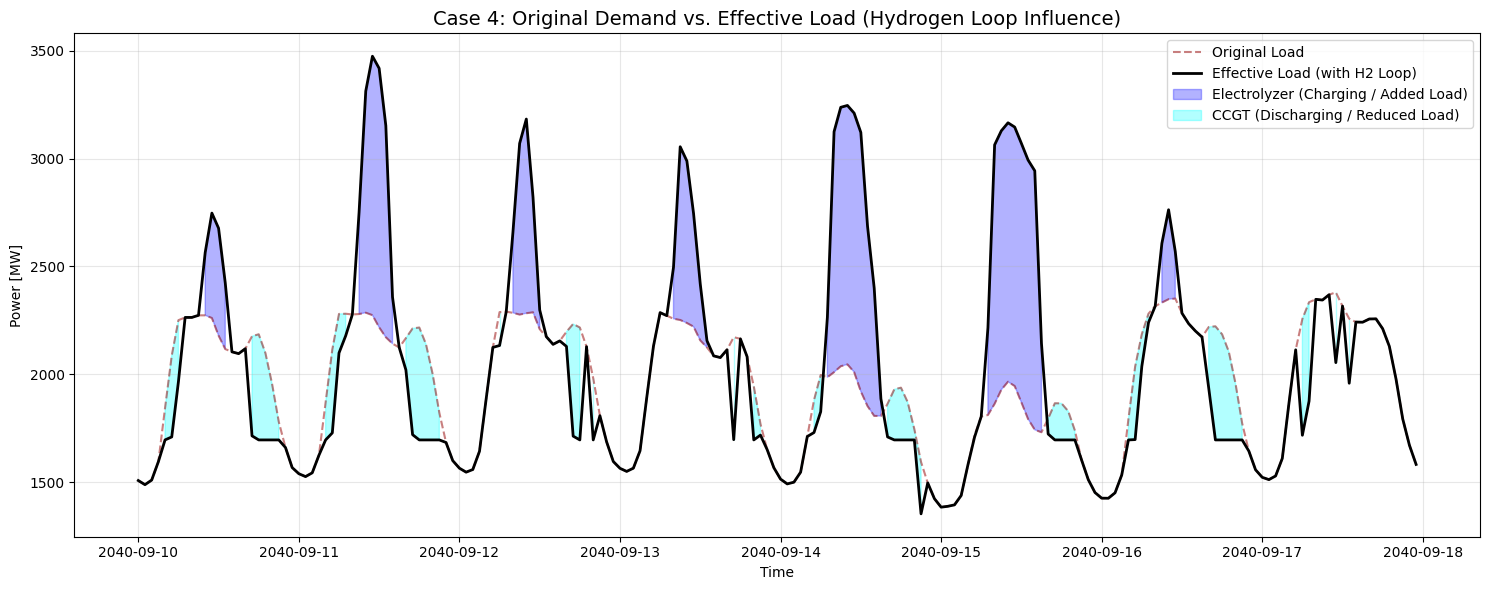

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract flows for Case 4
# Electrolyzer: p0 is power consumed (added demand)
# CCGT: p1 is power delivered (negative value in PyPSA, so -p1 is positive electricity)
electrolyzer_load = n_c4.links_t.p0['Electrolyzer']
ccgt_gen = -n_c4.links_t.p1['CCGT']
original_load_c4 = n_c4.loads_t.p['Load_elec']

# Effective load = Original + Electrolyzer - CCGT
effective_load_c4 = original_load_c4 + electrolyzer_load - ccgt_gen

plt.figure(figsize=(15, 6))
plt.plot(n_c4.snapshots, original_load_c4, label="Original Load", color="brown", linestyle="--", alpha=0.6)
plt.plot(n_c4.snapshots, effective_load_c4, label="Effective Load (with H2 Loop)", color="black", linewidth=2)

# Fill areas to show Hydrogen system activity
plt.fill_between(n_c4.snapshots, original_load_c4, effective_load_c4,
                 where=(electrolyzer_load > 10),
                 color="blue", alpha=0.3, label="Electrolyzer (Charging / Added Load)")

plt.fill_between(n_c4.snapshots, original_load_c4, effective_load_c4,
                 where=(ccgt_gen > 10),
                 color="cyan", alpha=0.3, label="CCGT (Discharging / Reduced Load)")

plt.title("Case 4: Original Demand vs. Effective Load (Hydrogen Loop Influence)", fontsize=14)
plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Price Metrics Comparison ---


,Mean Price [EUR/MWh],Median Price [EUR/MWh],Max Price [EUR/MWh],Hours at 85 EUR (%),Hours at 63 EUR (%)
Case 2 (Base),58.03,63.0,85.0,41.67,33.33
Case 3 (Storage),59.84,63.0,85.0,14.06,33.33
Case 4 (Target),62.28,63.0,85.0,38.54,36.98


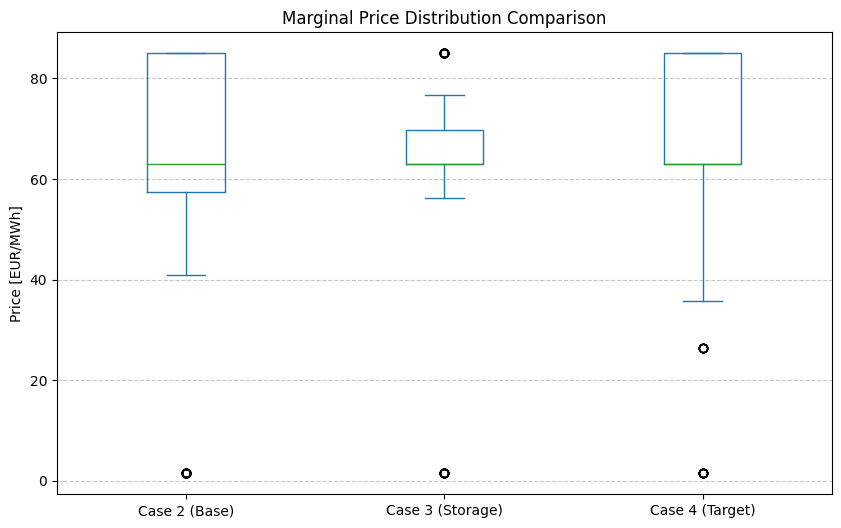

In [ ]:
import pandas as pd

# Collect marginal prices from all three cases
prices_df = pd.DataFrame({
    'Case 2 (Base)': n_c2.buses_t.marginal_price['Elec'],
    'Case 3 (Storage)': n_c3.buses_t.marginal_price['Elec'],
    'Case 4 (Target)': n_c4.buses_t.marginal_price['Elec']
})

# Calculate metrics
stats = pd.DataFrame({
    'Mean Price [EUR/MWh]': prices_df.mean(),
    'Median Price [EUR/MWh]': prices_df.median(),
    'Max Price [EUR/MWh]': prices_df.max(),
    'Hours at 85 EUR (%)': (prices_df == 85).mean() * 100,
    'Hours at 63 EUR (%)': (prices_df == 63).mean() * 100
})

print("--- Price Metrics Comparison ---")
display(stats.round(2))

# Plotting the price distributions
import matplotlib.pyplot as plt
prices_df.plot(kind='box', figsize=(10, 6), title='Marginal Price Distribution Comparison')
plt.ylabel('Price [EUR/MWh]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

# Create a comparison table for Total Cost vs. Average Marginal Price
comparison_metrics = pd.DataFrame({
    'Total System Cost [EUR]': [
        n_c2.objective,
        n_c3.objective,
        n_c4.objective
    ],
    'Avg Marginal Price [EUR/MWh]': [
        n_c2.buses_t.marginal_price['Elec'].mean(),
        n_c3.buses_t.marginal_price['Elec'].mean(),
        n_c4.buses_t.marginal_price['Elec'].mean()
    ]
}, index=['Case 2 (Base)', 'Case 3 (Battery)', 'Case 4 (H2 Arbitrage)'])

print("--- System Cost vs. Market Price ---")
display(comparison_metrics.style.format({'Total System Cost [EUR]': '{:,.0f}', 'Avg Marginal Price [EUR/MWh]': '{:.2f}'}))

--- System Cost vs. Market Price ---


,Total System Cost [EUR],Avg Marginal Price [EUR/MWh]
Case 2 (Base),"11,594,414",58.03
Case 3 (Battery),"10,295,476",59.84
Case 4 (H2 Arbitrage),"10,453,210",62.28
